## Imports & setup


In a transformer model, tokens are the sections of an input sequence. In this case, the model takes in a sequence of patch tokens. These are then projected into a higher dimensional space (d_model) to create embeddings (numerical representations) based on the input tokens. These embeddings are then processed and adjusted through the transformer layers, which allows them to be contextualized based on the relationships between the token embeddings via the attention mechanism and further adjusted through feedforward layers, which perform non-linear learned transformations on the embeddings.


Those patch tokens are sections of the input sequence, and the size of those patches is determined by the `patch_length` parameter. This controls how many days of data are grouped together into a single token.

In [15]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from transformers import PatchTSTConfig, PatchTSTModel

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # was super slow on CPU, so use MPS if available (MacOS GPU acceleration)
print("device:", DEVICE)

DATA_DIR = "../london_final_dataset"
TARGET = "pm25"
DROP_COLS = ["date", TARGET]
MODEL_DIR = Path("saved_patchtst")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("transformer_results")
RESULTS_DIR.mkdir(exist_ok=True)

FORECAST_HORIZONS = [7, 14, 30]  # predict PM2.5 this many days ahead

NUM_EPOCHS = 1000
TUNE_EPOCHS = 100  # fewer epochs during grid search
EARLY_STOP_PATIENCE = 200  # final fit: stop if validation MSE does not improve
FINAL_VAL_FRACTION = 0.2  # last fraction of train sequences for final-fit early stopping
CV_SPLITS = 5  # time-series cross-validation folds

DROPOUT = 0.4 # massive overfitting so increased from 0.2 to 0.4
N_HEADS = 4 #PatchTST default is 4, so we will keep it at 4 for now. Increasing n_heads increases model capacity, but also increases overfitting on small datasets (compute limited).

PARAM_GRID = {
    "learning_rate": [1e-3, 1e-4], # adam default is 1e-3 and patchTST official implementation uses use 1e-4, so these are the two values to try
    "d_model": [16, 32, 64], # d_model here is the embedding size for the transformer, larger d_model = more capacity, but also more prone to overfitting on small datasets (compute limited)
    "num_layers": [1, 2],
    "weight_decay": [0.0, 1e-4, 1e-3, 1e-2],

    # patch_length is the size of the tokens for the input sequence, so a patch_length of 5 means the model sees 5 days per token.
    # This allows it to attend to a '5' day tokens during attention, rather than attending to each day individually. 
    # these numbers need to be divisors of the input sequence length (30 days), so 5 and 10 are valid, 7 would lead to dropping 2 days of data.
    # larger patches = coarser time resolution (less day-to-day detail, fewer tokens).
    "patch_length": [2, 5, 10], 
}

device: mps


## Load train & test data


In [16]:
train_df = pd.read_csv(f"{DATA_DIR}/marylebone_train.csv", parse_dates=["date"])
test_df = pd.read_csv(f"{DATA_DIR}/marylebone_test.csv", parse_dates=["date"])

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()


Train: (1000, 42)
Test: (364, 42)


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## Split features & target


In [17]:
X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET]

feature_cols = X_train.columns.tolist()
print("Features:", len(feature_cols), "| train", X_train.shape, "| test", X_test.shape)


Features: 40 | train (1000, 40) | test (364, 40)


## Scale features & target


In [18]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),  # fit on train only (no leakage)
    columns=feature_cols,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index,
)

# Target scaling (train-fit only). Train in scaled space, report metrics in µg/m³ after inverse.
y_scaler = StandardScaler()
y_train_scaled = pd.Series(
    y_scaler.fit_transform(y_train.to_numpy().reshape(-1, 1)).ravel(),
    index=y_train.index,
    name=TARGET,
)
y_test_scaled = pd.Series(
    y_scaler.transform(y_test.to_numpy().reshape(-1, 1)).ravel(),
    index=y_test.index,
    name=TARGET,
)

print(
    f"y_train mean={y_scaler.mean_[0]:.3f}, std={y_scaler.scale_[0]:.3f} "
    f"(scaled train mean≈{y_train_scaled.mean():.3f}, std={y_train_scaled.std():.3f})"
)
X_train_scaled.describe().round(3)


y_train mean=8.490, std=4.988 (scaled train mean≈0.000, std=1.001)


,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,season_code,...,mean_air_pressure_hpa,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,...,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,...,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.387,-1.799,-1.688,-1.500,-1.931,-1.891,-1.541,-0.633,-1.580,-1.465,...,-4.423,-4.113,-4.731,-2.570,-3.062,-2.813,-1.570,-1.873,-1.424,-2.203
25%,-1.387,-0.891,-0.891,-1.000,-0.793,-0.781,-0.605,-0.633,-1.580,-0.555,...,-0.564,-0.545,-0.563,-0.731,-0.646,-0.706,-0.762,-0.631,-0.830,-0.788
50%,-0.123,0.017,0.020,-0.000,0.029,0.051,0.330,-0.633,0.633,0.355,...,0.066,0.047,0.102,0.010,0.089,-0.003,-0.196,-0.011,-0.236,0.260
75%,1.142,0.925,0.817,0.999,0.853,0.884,1.266,1.580,0.633,1.265,...,0.654,0.667,0.666,0.723,0.730,0.734,0.608,0.610,0.357,0.651
max,1.142,1.530,1.728,1.499,1.682,1.647,1.266,1.580,0.633,1.265,...,2.779,2.877,2.428,3.515,2.164,3.050,4.213,5.266,5.702,1.825


## PatchTST implementation


### Create sequences


In [19]:
_INPUT_WINDOW = 30


def create_sequences(X, y, horizon, input_window=_INPUT_WINDOW):
    """Past window of features → PM2.5 for every day from tomorrow through +horizon.

    If the input window ends on day t, the target is
    [y[t+1], y[t+2], ..., y[t+horizon]]  (length = horizon).

    Built over the full series passed in (all training / all test rows).
    """
    Xs, ys = [], []
    for i in range(len(X) - input_window - horizon + 1):
        Xs.append(X[i : i + input_window])
        ys.append(y[i + input_window : i + input_window + horizon])
    return np.array(Xs), np.array(ys)


In [20]:
def make_tensors(X_df, y_series, horizon):
    """Scaled feature matrix + scaled target → PatchTST X and multi-step Y."""
    X_seq, y_seq = create_sequences(X_df.to_numpy(), y_series.to_numpy(), horizon)
    X = torch.tensor(X_seq, dtype=torch.float32, device=DEVICE)  # (batch, days, features)
    y = torch.tensor(y_seq, dtype=torch.float32, device=DEVICE)  # (batch, horizon), scaled
    return X, y


def inverse_target(y_scaled):
    """Scaled target array (N,) or (N, H) → original µg/m³."""
    arr = np.asarray(y_scaled, dtype=float)
    shape = arr.shape
    return y_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(shape)


def time_ordered_train_val_split(X, y, val_fraction=FINAL_VAL_FRACTION):
    """Hold out the last `val_fraction` of sequences for validation (time-ordered)."""
    n = len(X)
    n_val = max(1, int(round(n * val_fraction)))
    n_fit = n - n_val
    if n_fit < 1:
        raise ValueError(f"val_fraction={val_fraction} leaves no training sequences (n={n})")
    return X[:n_fit], y[:n_fit], X[n_fit:], y[n_fit:]


n_features = X_train_scaled.shape[1]


### Training helpers


In [21]:
def rmse(y_true, y_pred):
    return float(mean_squared_error(y_true, y_pred) ** 0.5)


def evaluate_mae(model, X, y):
    """MAE in original µg/m³ (inverse-transforms scaled preds/targets)."""
    model.eval()
    with torch.no_grad():
        pred = model(X).detach().cpu().numpy()
    y_true = inverse_target(y.cpu().numpy())
    y_pred = inverse_target(pred)
    return float(mean_absolute_error(y_true.ravel(), y_pred.ravel()))


def print_metrics(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_v = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{name:6s}  MAE: {mae:.3f}  RMSE: {rmse_v:.3f}")


In [22]:
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    lr,
    weight_decay,
    epochs,
    log_every=None,
    restore_best=True,
    patience=None,
):
    """Full-batch Adam training.

    If restore_best=True, reloads weights from the lowest validation-loss epoch.
    If patience is set, stop when validation loss does not improve for `patience` epochs.
    Returns train_losses, val_losses, best_epoch (0-based).
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []
    best_epoch, best_val, best_state = 0, float("inf"), None
    epochs_since_improve = 0

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        if log_every and (epoch % log_every == 0 or epoch == epochs - 1):
            print(
                f"Epoch: {epoch:3d}, train: {loss.item():.5f}, "
                f"val: {val_loss:.5f}"
            )

        if patience is not None and epochs_since_improve >= patience:
            print(
                f"Early stopping at epoch {epoch} "
                f"(no validation improvement for {patience} epochs; best={best_epoch})"
            )
            break

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
    else:
        best_epoch = len(train_losses) - 1

    return train_losses, val_losses, best_epoch


In [23]:
def plot_train_val_loss(
    train_losses,
    val_losses,
    best_epoch=None,
    title="Train vs validation loss",
    val_label="Validation",
):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label=val_label)
    if best_epoch is not None:
        plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch={best_epoch}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Define PatchTST model


In order to forecast the target variable, we need an output layer (head) that takes the output of the encoder and produce a multi step forecast. The PatchTST encoder outputs a tensor of shape (batch, channels, patches, d_model). 

PatchTST splits the each feature (wind_speed) into patches, based on there position in the input sequence (when they occur in time). The amount of days worth of feature data that is grouped together into a single patch is determined by the `patch_length` parameter. So if we have 30 days worth of 'wind_speed' data, and a `patch_length` of 5, then we will have 6 patches for that feature. 

We then get the mean average over all our patches (which has at this point been processed through the transformer layers) for all features creating a single vector of size d_model (the embedding size) for each sample in the batch. This is then passed through a linear layer to produce a multi-step forecast of the target variable (so combined representation of all features is used to forecast the target variable across the forecast horizon).

Pooled means many vectors (every patch embedding for every feature) collapsed into a single summary vector (the mean of all the patch embeddings).

Another important thing to remember is that those patches are tokens and the 'patch_length' parameter controls how many days of data are grouped together into a single token. These tokens are then turned into a vector representation (embedding) of size d_model, which is then processed through the transformer layers to contextualize the embeddings based on the relationships between the tokens via the attention mechanism and each token is then further adjusted through feedforward layers, which perform non-linear learned transformations on the embeddings.

#### Channel independent attention is used in PatchTST:

Each feature (channel) patches (grouped days of data) are treated independently, and the attention mechanism is applied separately to each feature. This means that the model learns relationships between patches within each feature, but not across features.

The same learned weights so: attention weights (key, query, value projections) and feedforward weights are shared across all features, just the attention is applied independently to each feature.

In [24]:
class PatchTSTForecaster(nn.Module):
    """Hugging Face PatchTST encoder + linear head to multi-step PM2.5."""

    def __init__(
        self,
        n_features,
        context_length,
        horizon,
        d_model=64,
        num_layers=2,
        patch_length=5,
        dropout=DROPOUT,
        n_heads=N_HEADS,
    ):
        super().__init__()
        config = PatchTSTConfig(
            num_input_channels=n_features,
            context_length=context_length,
            patch_length=patch_length,
            patch_stride=patch_length,
            prediction_length=horizon,
            d_model=d_model,
            num_attention_heads=n_heads,
            num_hidden_layers=num_layers,
            ffn_dim=d_model * 2,
            attention_dropout=dropout, # ddropout on attention weights after softmax
            positional_dropout=dropout, # dropout after adding positional encodings
            path_dropout=dropout,# residual dropout around attention and FFN
            ff_dropout=dropout, # dropout between the two FFN layers
            pooling_type=None,
            channel_attention=False,
            scaling=None,  # already StandardScaled
            loss="mse",
            pre_norm=True,
            norm_type="batchnorm",
        )
        self.backbone = PatchTSTModel(config)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, horizon)) # more dropout before the linear head to combat overfitting on small dataset

    def forward(self, x):
        # x: (batch, days, features)
        hidden = self.backbone(past_values=x).last_hidden_state 
        # PatchTST: (batch, channels, patches, d_model)
        pooled = hidden.mean(dim=(1, 2)) # average over all channel (feature) patches to get a single vector of size d_model
        return self.head(pooled) # linear head returns (batch, horizon) multi-step forecast of PM2.5 based on the pooled representation from the PatchTST encoder.


def build_model(d_model, num_layers, patch_length, horizon=7):
    return PatchTSTForecaster(
        n_features=n_features,
        context_length=_INPUT_WINDOW,
        horizon=horizon,
        d_model=d_model,
        num_layers=num_layers,
        patch_length=patch_length,
    ).to(DEVICE) # move model to the device (CPU or MPS) to speed up training and inference.


## Hyperparameter tuning


In [11]:
param_keys = list(PARAM_GRID.keys())
param_combos = list(itertools.product(*PARAM_GRID.values()))
tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

print(f"{len(param_combos)} configs × {CV_SPLITS} folds × {TUNE_EPOCHS} tune epochs")


144 configs × 5 folds × 100 tune epochs


### Grid-search helper


In [12]:
def cv_grid_search(trainX, trainY):
    """Time-series CV grid search. Returns (results_df, best_dict).

    best_epoch = argmin of the *mean* validation-loss curve across folds
    (so it matches the plotted mean train/val curves).
    """
    rows = []
    best = None

    for i, values in enumerate(param_combos, start=1):
        params = dict(zip(param_keys, values))
        fold_train_maes, fold_val_maes = [], []
        fold_train_curves, fold_val_curves = [], []

        for fold, (tr_idx, va_idx) in enumerate(tscv.split(np.arange(len(trainX))), start=1):
            torch.manual_seed(42 + fold)
            horizon = trainY.shape[1]
            model_i = build_model(
                params["d_model"],
                params["num_layers"],
                params["patch_length"],
                horizon=horizon,
            )
            train_losses_i, val_losses_i, _ = train_model(
                model_i,
                trainX[tr_idx],
                trainY[tr_idx],
                trainX[va_idx],
                trainY[va_idx],
                lr=params["learning_rate"],
                weight_decay=params["weight_decay"],
                epochs=TUNE_EPOCHS,
                restore_best=True,
            )
            fold_train_maes.append(evaluate_mae(model_i, trainX[tr_idx], trainY[tr_idx]))
            fold_val_maes.append(evaluate_mae(model_i, trainX[va_idx], trainY[va_idx]))
            fold_train_curves.append(train_losses_i)
            fold_val_curves.append(val_losses_i)

        mean_train_curve = np.mean(fold_train_curves, axis=0)
        mean_val_curve = np.mean(fold_val_curves, axis=0)
        best_epoch = int(np.argmin(mean_val_curve))

        mean_val_mae = float(np.mean(fold_val_maes))
        std_val_mae = float(np.std(fold_val_maes))

        rows.append(
            {
                **params,
                "train_mae": float(np.mean(fold_train_maes)),
                "val_mae": mean_val_mae,
                "val_mae_std": std_val_mae,
                "best_epoch": best_epoch,
                **{f"val_mae_fold{k + 1}": fold_val_maes[k] for k in range(CV_SPLITS)},
            }
        )

        is_best = best is None or mean_val_mae < best["val_mae"]
        if is_best:
            best = {
                "val_mae": mean_val_mae,
                "params": params,
                "best_epoch": best_epoch,
                "train_losses": mean_train_curve,
                "val_losses": mean_val_curve,
                "fold_val_maes": fold_val_maes,
            }
            print(
                f"  new best [{i}/{len(param_combos)}] "
                f"CV MAE={mean_val_mae:.3f} ± {std_val_mae:.3f}  {params}"
            )
        elif i % 40 == 0:
            print(f"  [{i}/{len(param_combos)}] ...")

    results_df = pd.DataFrame(rows).sort_values("val_mae").reset_index(drop=True)
    return results_df, best


### Forecast horizon: 7 days


In [13]:
# Sequences for horizon = 7 (scaled targets)
trainX_7, trainY_7 = make_tensors(X_train_scaled, y_train_scaled, 7)
testX_7, testY_7 = make_tensors(X_test_scaled, y_test_scaled, 7)
print("train:", tuple(trainX_7.shape), "test:", tuple(testX_7.shape))


train: (964, 30, 40) test: (328, 30, 40)


#### Grid search (h=7)


In [14]:
print("Grid search for horizon=7d")
results_df_7, best_7 = cv_grid_search(trainX_7, trainY_7)
best_params_7 = best_7["params"]
best_epoch_7 = best_7["best_epoch"]
print("\nBest params (by mean CV MAE):", best_params_7)
print(f"CV MAE = {best_7['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_7}")
plot_train_val_loss(
    best_7["train_losses"],
    best_7["val_losses"],
    best_epoch=best_epoch_7,
    title="h=7d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


Grid search for horizon=7d
  new best [1/144] CV MAE=3.571 ± 0.796  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 2}
  new best [14/144] CV MAE=3.545 ± 0.815  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 5}
  new best [17/144] CV MAE=3.538 ± 0.818  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0001, 'patch_length': 5}
  new best [26/144] CV MAE=3.492 ± 0.847  {'learning_rate': 0.001, 'd_model': 32, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 5}


KeyboardInterrupt: 

### Hyperparameter tuning plots


In [57]:
def plot_tuning_results(results_df, horizon, top_n=12):
    """Standard HPO views of CV validation MAE (lower is better)."""
    df = results_df.copy()
    df["config"] = (
        "lr=" + df["learning_rate"].astype(str)
        + ", d=" + df["d_model"].astype(str)
        + ", L=" + df["num_layers"].astype(str)
        + ", p=" + df["patch_length"].astype(str)
        + ", wd=" + df["weight_decay"].astype(str)
    )

    top = df.nsmallest(top_n, "val_mae").sort_values("val_mae", ascending=False)
    plt.figure(figsize=(9, 5))
    plt.barh(top["config"], top["val_mae"], color="steelblue")
    plt.xlabel("Mean CV validation MAE")
    plt.title(f"h={horizon}d — top {top_n} configs by CV val MAE")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x="learning_rate", y="val_mae", color="lightgray")
    sns.stripplot(data=df, x="learning_rate", y="val_mae", color="steelblue", size=5, jitter=0.15)
    plt.ylabel("Mean CV validation MAE")
    plt.xlabel("Learning rate")
    plt.title(f"h={horizon}d — CV val MAE by learning rate")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.pointplot(
        data=df,
        x="d_model",
        y="val_mae",
        hue="learning_rate",
        errorbar="sd",
        dodge=True,
    )
    plt.ylabel("Mean CV validation MAE")
    plt.xlabel("d_model")
    plt.title(f"h={horizon}d — CV val MAE vs d_model (by learning rate)")
    plt.legend(title="learning_rate")
    plt.tight_layout()
    plt.show()

    size_mat = df.pivot_table(
        index="d_model",
        columns="patch_length",
        values="val_mae",
        aggfunc="mean",
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(size_mat, annot=True, fmt=".3f", cmap="viridis_r")
    plt.xlabel("patch_length")
    plt.ylabel("d_model")
    plt.title(f"h={horizon}d — CV val MAE by model size (d_model × patch)")
    plt.tight_layout()
    plt.show()

    reg_mat = df.pivot_table(
        index="weight_decay",
        columns="learning_rate",
        values="val_mae",
        aggfunc="mean",
    )
    reg_mat.index = [f"{w:g}" for w in reg_mat.index]
    plt.figure(figsize=(5.5, 3.5))
    sns.heatmap(reg_mat, annot=True, fmt=".3f", cmap="viridis_r")
    plt.xlabel("Learning rate")
    plt.ylabel("Weight decay (L2)")
    plt.title(f"h={horizon}d — CV val MAE by regularization (wd × lr)")
    plt.tight_layout()
    plt.show()


#### Hyperparameter tuning plots (h=7)


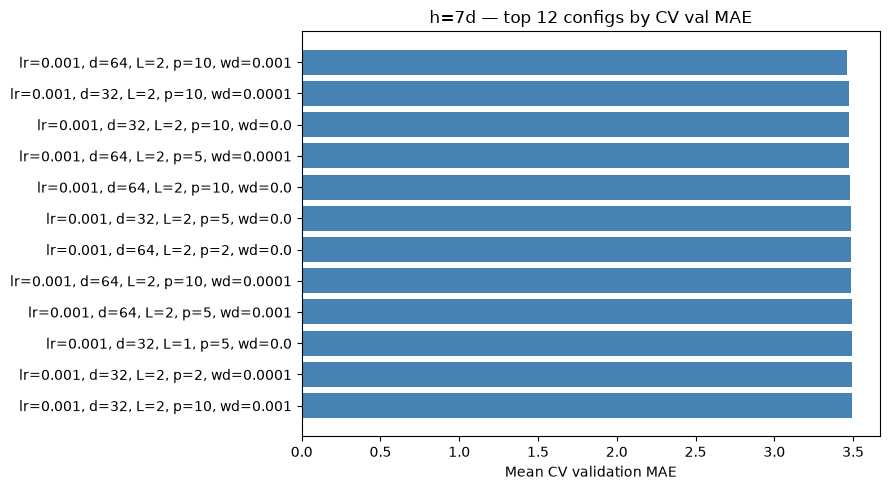

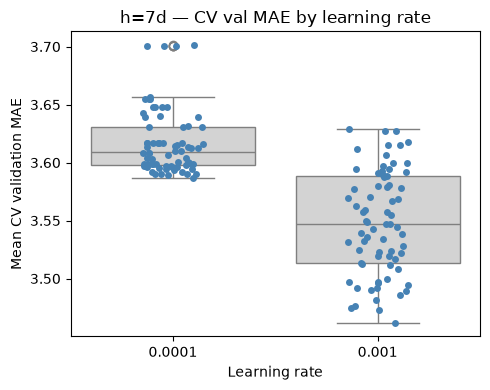

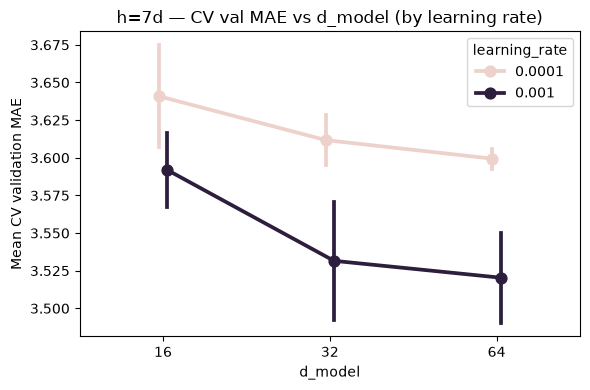

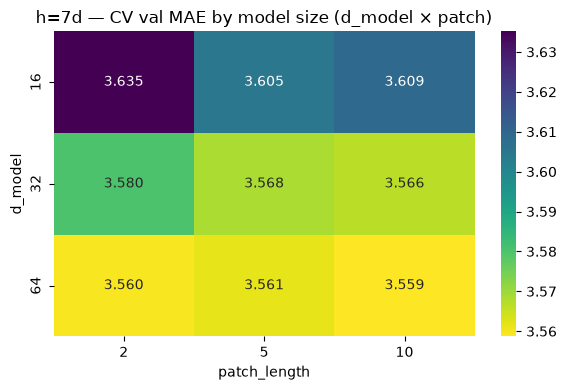

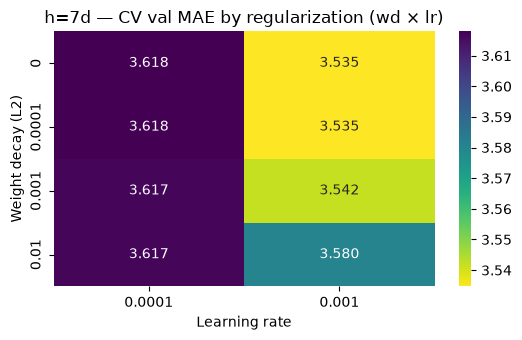

In [ ]:
plot_tuning_results(results_df_7, horizon=7)


#### Final fit (h=7)


In [ ]:
torch.manual_seed(42)
model_7 = build_model(
    best_params_7["d_model"],
    best_params_7["num_layers"],
    best_params_7["patch_length"],
    horizon=7,
)

fitX_7, fitY_7, valX_7, valY_7 = time_ordered_train_val_split(
    trainX_7, trainY_7, FINAL_VAL_FRACTION
)
train_losses_7, val_losses_7, best_epoch_7_final = train_model(
    model_7,
    fitX_7,
    fitY_7,
    valX_7,
    valY_7,
    lr=best_params_7["learning_rate"],
    weight_decay=best_params_7["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"Final fit h=7d: ran {len(train_losses_7)} epochs; "
    f"restored best validation epoch={best_epoch_7_final}"
)


Early stopping at epoch 273 (no validation improvement for 200 epochs; best=73)
Final fit h=7d: ran 274 epochs; restored best validation epoch=73


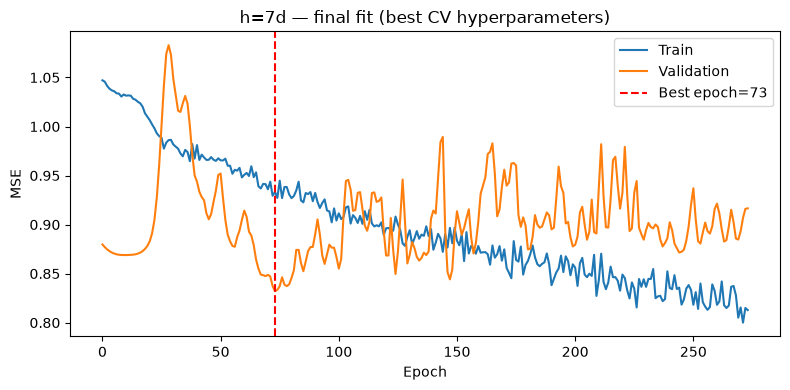

In [ ]:
plot_train_val_loss(
    train_losses_7,
    val_losses_7,
    best_epoch=best_epoch_7_final,
    title="h=7d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit / val (h=7)


In [ ]:
model_7.eval()
with torch.no_grad():
    fit_pred_7 = inverse_target(model_7(fitX_7).detach().cpu().numpy())
    val_pred_7 = inverse_target(model_7(valX_7).detach().cpu().numpy())

fit_true_7 = inverse_target(fitY_7.cpu().numpy())
val_true_7 = inverse_target(valY_7.cpu().numpy())

train_mae_7 = mean_absolute_error(fit_true_7.ravel(), fit_pred_7.ravel())
val_mae_7 = mean_absolute_error(val_true_7.ravel(), val_pred_7.ravel())
train_rmse_7 = rmse(fit_true_7.ravel(), fit_pred_7.ravel())
val_rmse_7 = rmse(val_true_7.ravel(), val_pred_7.ravel())

print_metrics("Fit", fit_true_7.ravel(), fit_pred_7.ravel())
print_metrics("Val", val_true_7.ravel(), val_pred_7.ravel())


Fit     MAE: 3.656  RMSE: 4.883
Val     MAE: 3.218  RMSE: 4.550


#### Save best model (h=7)


In [ ]:
save_path_7 = MODEL_DIR / "patchtst_h7.pt"
torch.save(
    {
        "model_state_dict": {k: v.detach().cpu() for k, v in model_7.state_dict().items()},
        "horizon": 7,
        "n_features": n_features,
        "best_params": best_params_7,
        "best_epoch": best_epoch_7_final,
        "num_epochs": len(train_losses_7),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_7["val_mae"],
        "train_mae": train_mae_7,
        "train_rmse": train_rmse_7,
        "val_mae": val_mae_7,
        "val_rmse": val_rmse_7,
    },
    save_path_7,
)
print(
    f"Saved → {save_path_7}  "
    f"(best val epoch={best_epoch_7_final}, ran {len(train_losses_7)} epochs)"
)


Saved → saved_patchtst/patchtst_h7.pt  (best val epoch=73, ran 274 epochs)


### Forecast horizon: 14 days


In [31]:
# Sequences for horizon = 14 (scaled targets)
trainX_14, trainY_14 = make_tensors(X_train_scaled, y_train_scaled, 14)
testX_14, testY_14 = make_tensors(X_test_scaled, y_test_scaled, 14)
print("train:", tuple(trainX_14.shape), "test:", tuple(testX_14.shape))


train: (957, 30, 40) test: (321, 30, 40)


#### Grid search (h=14)


Grid search for horizon=14d
  new best [1/144] CV MAE=3.598 ± 0.807  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 2}
  new best [2/144] CV MAE=3.587 ± 0.802  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 5}
  new best [5/144] CV MAE=3.586 ± 0.805  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0001, 'patch_length': 5}
  new best [13/144] CV MAE=3.582 ± 0.830  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 2}
  new best [15/144] CV MAE=3.581 ± 0.784  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 10}
  new best [17/144] CV MAE=3.554 ± 0.810  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0001, 'patch_length': 5}
  new best [20/144] CV MAE=3.553 ± 0.811  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.001, 'patch_lengt

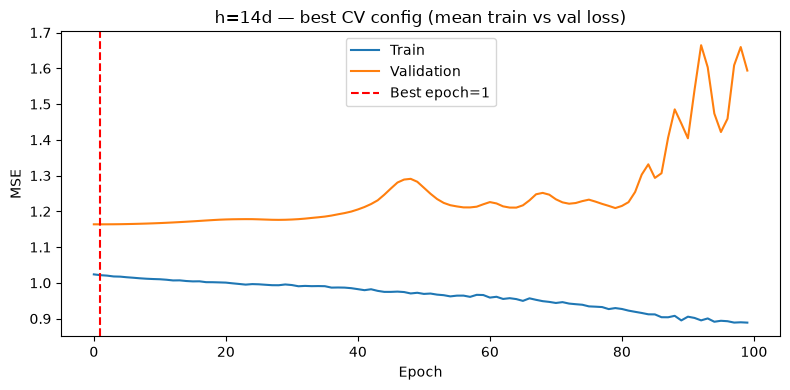

In [ ]:
print("Grid search for horizon=14d")
results_df_14, best_14 = cv_grid_search(trainX_14, trainY_14)
best_params_14 = best_14["params"]
best_epoch_14 = best_14["best_epoch"]
print("\nBest params (by mean CV MAE):", best_params_14)
print(f"CV MAE = {best_14['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_14}")
plot_train_val_loss(
    best_14["train_losses"],
    best_14["val_losses"],
    best_epoch=best_epoch_14,
    title="h=14d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=14)


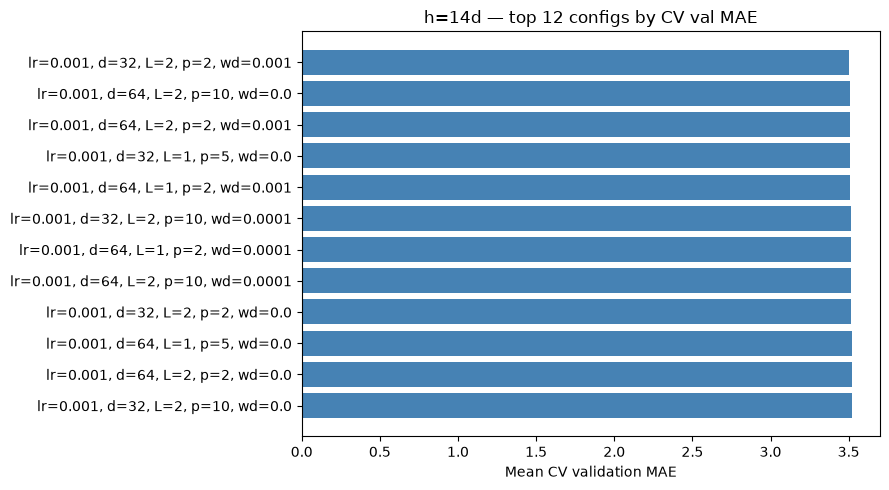

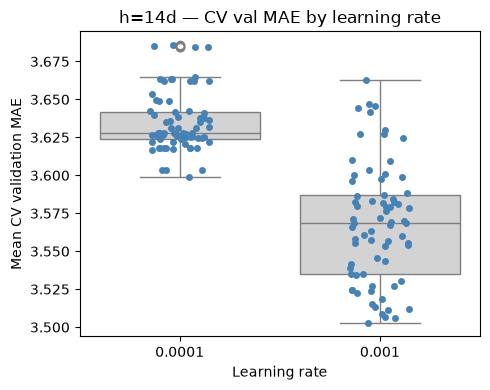

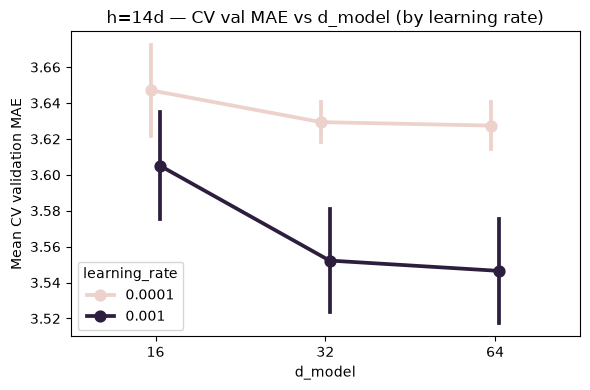

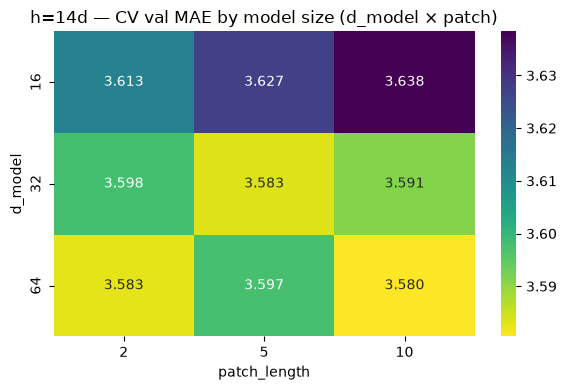

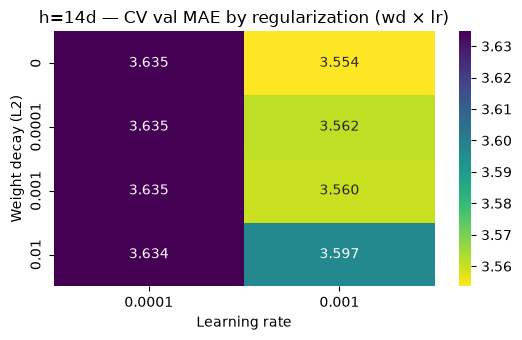

In [ ]:
plot_tuning_results(results_df_14, horizon=14)


#### Final fit (h=14)


In [ ]:
torch.manual_seed(42)
model_14 = build_model(
    best_params_14["d_model"],
    best_params_14["num_layers"],
    best_params_14["patch_length"],
    horizon=14,
)

fitX_14, fitY_14, valX_14, valY_14 = time_ordered_train_val_split(
    trainX_14, trainY_14, FINAL_VAL_FRACTION
)
train_losses_14, val_losses_14, best_epoch_14_final = train_model(
    model_14,
    fitX_14,
    fitY_14,
    valX_14,
    valY_14,
    lr=best_params_14["learning_rate"],
    weight_decay=best_params_14["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"Final fit h=14d: ran {len(train_losses_14)} epochs; "
    f"restored best validation epoch={best_epoch_14_final}"
)


Early stopping at epoch 241 (no validation improvement for 200 epochs; best=41)
Final fit h=14d: ran 242 epochs; restored best validation epoch=41


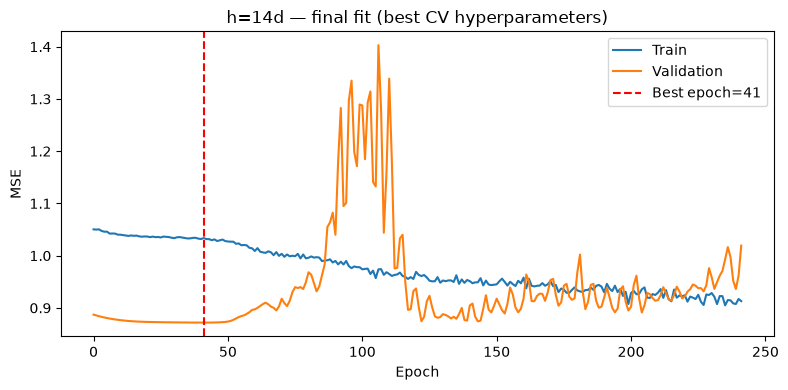

In [ ]:
plot_train_val_loss(
    train_losses_14,
    val_losses_14,
    best_epoch=best_epoch_14_final,
    title="h=14d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit / val (h=14)


In [ ]:
model_14.eval()
with torch.no_grad():
    fit_pred_14 = inverse_target(model_14(fitX_14).detach().cpu().numpy())
    val_pred_14 = inverse_target(model_14(valX_14).detach().cpu().numpy())

fit_true_14 = inverse_target(fitY_14.cpu().numpy())
val_true_14 = inverse_target(valY_14.cpu().numpy())

train_mae_14 = mean_absolute_error(fit_true_14.ravel(), fit_pred_14.ravel())
val_mae_14 = mean_absolute_error(val_true_14.ravel(), val_pred_14.ravel())
train_rmse_14 = rmse(fit_true_14.ravel(), fit_pred_14.ravel())
val_rmse_14 = rmse(val_true_14.ravel(), val_pred_14.ravel())

print_metrics("Fit", fit_true_14.ravel(), fit_pred_14.ravel())
print_metrics("Val", val_true_14.ravel(), val_pred_14.ravel())


Fit     MAE: 3.356  RMSE: 5.068
Val     MAE: 3.236  RMSE: 4.657


#### Save best model (h=14)


In [ ]:
save_path_14 = MODEL_DIR / "patchtst_h14.pt"
torch.save(
    {
        "model_state_dict": {k: v.detach().cpu() for k, v in model_14.state_dict().items()},
        "horizon": 14,
        "n_features": n_features,
        "best_params": best_params_14,
        "best_epoch": best_epoch_14_final,
        "num_epochs": len(train_losses_14),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_14["val_mae"],
        "train_mae": train_mae_14,
        "train_rmse": train_rmse_14,
        "val_mae": val_mae_14,
        "val_rmse": val_rmse_14,
    },
    save_path_14,
)
print(
    f"Saved → {save_path_14}  "
    f"(best val epoch={best_epoch_14_final}, ran {len(train_losses_14)} epochs)"
)


Saved → saved_patchtst/patchtst_h14.pt  (best val epoch=41, ran 242 epochs)


### Forecast horizon: 30 days


In [32]:
# Sequences for horizon = 30 (scaled targets)
trainX_30, trainY_30 = make_tensors(X_train_scaled, y_train_scaled, 30)
testX_30, testY_30 = make_tensors(X_test_scaled, y_test_scaled, 30)
print("train:", tuple(trainX_30.shape), "test:", tuple(testX_30.shape))


train: (941, 30, 40) test: (305, 30, 40)


#### Grid search (h=30)


Grid search for horizon=30d
  new best [1/144] CV MAE=3.626 ± 0.833  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 2}
  new best [2/144] CV MAE=3.622 ± 0.832  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 5}
  new best [5/144] CV MAE=3.620 ± 0.833  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0001, 'patch_length': 5}
  new best [15/144] CV MAE=3.615 ± 0.825  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 10}
  new best [16/144] CV MAE=3.608 ± 0.833  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0001, 'patch_length': 2}
  new best [25/144] CV MAE=3.580 ± 0.857  {'learning_rate': 0.001, 'd_model': 32, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 2}
  new best [28/144] CV MAE=3.562 ± 0.864  {'learning_rate': 0.001, 'd_model': 32, 'num_layers': 1, 'weight_decay': 0.0001, 'patch_leng

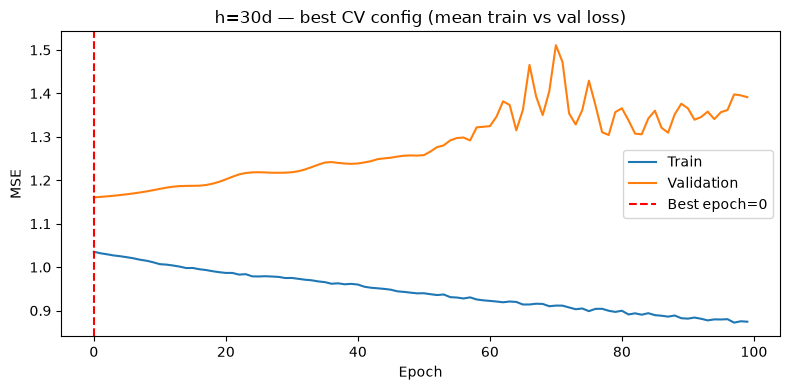

In [ ]:
print("Grid search for horizon=30d")
results_df_30, best_30 = cv_grid_search(trainX_30, trainY_30)
best_params_30 = best_30["params"]
best_epoch_30 = best_30["best_epoch"]
print("\nBest params (by mean CV MAE):", best_params_30)
print(f"CV MAE = {best_30['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_30}")
plot_train_val_loss(
    best_30["train_losses"],
    best_30["val_losses"],
    best_epoch=best_epoch_30,
    title="h=30d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=30)


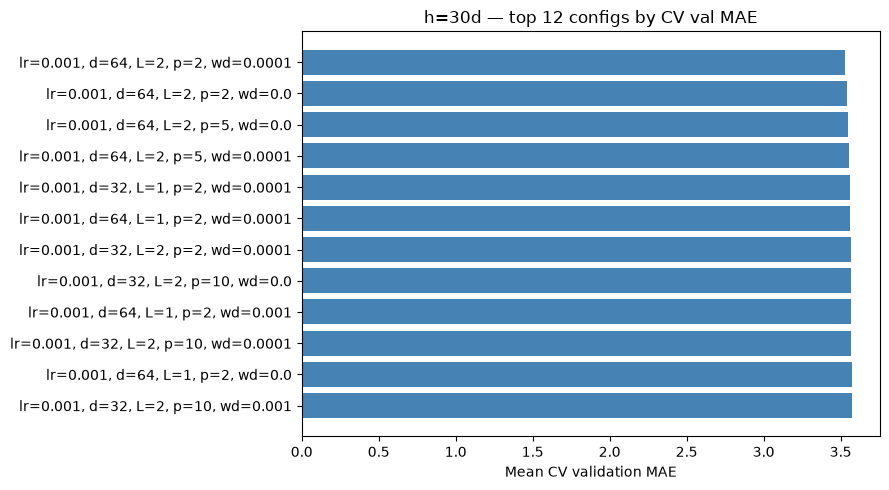

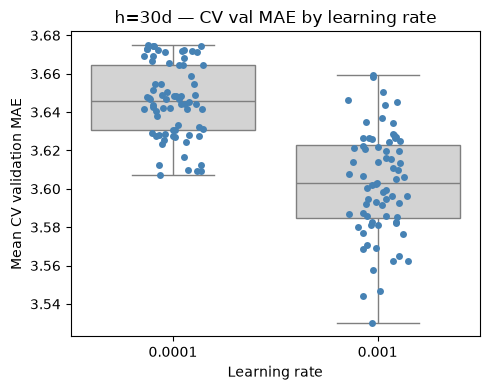

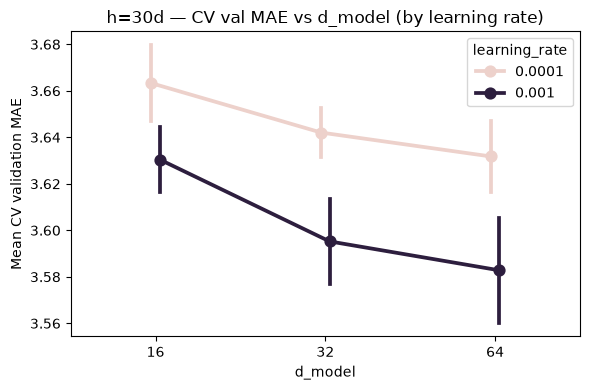

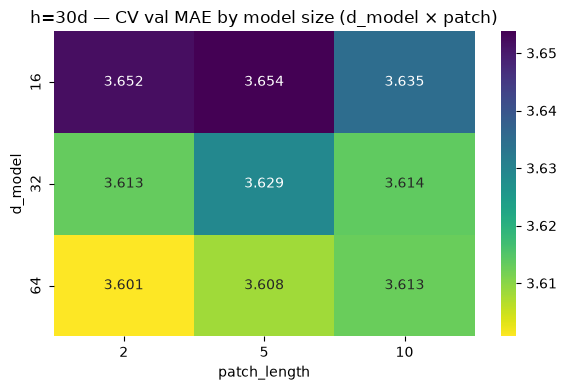

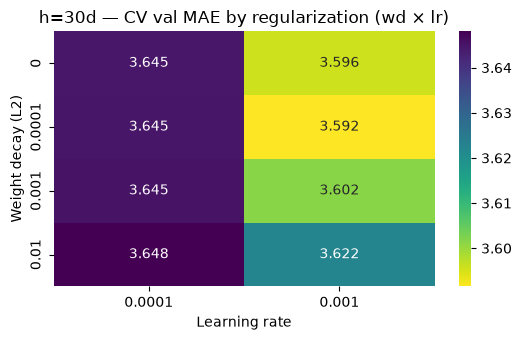

In [ ]:
plot_tuning_results(results_df_30, horizon=30)


#### Final fit (h=30)


In [ ]:
torch.manual_seed(42)
model_30 = build_model(
    best_params_30["d_model"],
    best_params_30["num_layers"],
    best_params_30["patch_length"],
    horizon=30,
)

fitX_30, fitY_30, valX_30, valY_30 = time_ordered_train_val_split(
    trainX_30, trainY_30, FINAL_VAL_FRACTION
)
train_losses_30, val_losses_30, best_epoch_30_final = train_model(
    model_30,
    fitX_30,
    fitY_30,
    valX_30,
    valY_30,
    lr=best_params_30["learning_rate"],
    weight_decay=best_params_30["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"Final fit h=30d: ran {len(train_losses_30)} epochs; "
    f"restored best validation epoch={best_epoch_30_final}"
)


Early stopping at epoch 274 (no validation improvement for 200 epochs; best=74)
Final fit h=30d: ran 275 epochs; restored best validation epoch=74


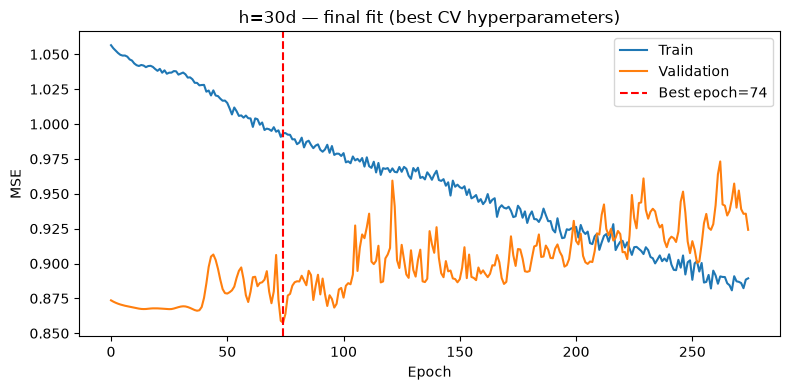

In [ ]:
plot_train_val_loss(
    train_losses_30,
    val_losses_30,
    best_epoch=best_epoch_30_final,
    title="h=30d — final fit (best CV hyperparameters)",
    val_label="Validation",
)


#### Evaluate fit / val (h=30)


In [ ]:
model_30.eval()
with torch.no_grad():
    fit_pred_30 = inverse_target(model_30(fitX_30).detach().cpu().numpy())
    val_pred_30 = inverse_target(model_30(valX_30).detach().cpu().numpy())

fit_true_30 = inverse_target(fitY_30.cpu().numpy())
val_true_30 = inverse_target(valY_30.cpu().numpy())

train_mae_30 = mean_absolute_error(fit_true_30.ravel(), fit_pred_30.ravel())
val_mae_30 = mean_absolute_error(val_true_30.ravel(), val_pred_30.ravel())
train_rmse_30 = rmse(fit_true_30.ravel(), fit_pred_30.ravel())
val_rmse_30 = rmse(val_true_30.ravel(), val_pred_30.ravel())

print_metrics("Fit", fit_true_30.ravel(), fit_pred_30.ravel())
print_metrics("Val", val_true_30.ravel(), val_pred_30.ravel())


Fit     MAE: 3.605  RMSE: 5.024
Val     MAE: 3.251  RMSE: 4.619


#### Save best model (h=30)


In [ ]:
save_path_30 = MODEL_DIR / "patchtst_h30.pt"
torch.save(
    {
        "model_state_dict": {k: v.detach().cpu() for k, v in model_30.state_dict().items()},
        "horizon": 30,
        "n_features": n_features,
        "best_params": best_params_30,
        "best_epoch": best_epoch_30_final,
        "num_epochs": len(train_losses_30),
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "final_val_fraction": FINAL_VAL_FRACTION,
        "dropout": DROPOUT,
        "y_scaler": y_scaler,
        "cv_val_mae": best_30["val_mae"],
        "train_mae": train_mae_30,
        "train_rmse": train_rmse_30,
        "val_mae": val_mae_30,
        "val_rmse": val_rmse_30,
    },
    save_path_30,
)
print(
    f"Saved → {save_path_30}  "
    f"(best val epoch={best_epoch_30_final}, ran {len(train_losses_30)} epochs)"
)


Saved → saved_patchtst/patchtst_h30.pt  (best val epoch=74, ran 275 epochs)


#### Hyperparameter tuning summary

We grid-searched 144 configurations at each of 7, 14, and 30 days: learning rate, d_model, layer count, weight decay, and patch length. Dropout stayed at 0.4, attention heads at 4. We picked the winner by mean CV MAE, then refit it on a time-ordered train/validation split with early stopping on validation MSE. The test set stayed unused until evaluation.

All three winners used a learning rate of 0.001 and two transformer layers. They still differed on width and patch size. The 7-day model used the largest embedding, d_model=64, stronger L2 at weight_decay=0.001, and the coarsest patches, patch_length=10, three tokens from the 30-day window. The 14-day model used d_model=32, the same weight decay, and patch_length=2. The 30-day model used d_model=64, weaker L2 at 0.0001, and patch_length=2.

That split is not a real architecture story. Mean CV MAE is 3.462 at 7 days, 3.503 at 14, and 3.530 at 30. First grid point to winner is 0.109, 0.095, and 0.096 µg/m³. Fold spread on the winners is 3.462 ± 0.838, 3.503 ± 0.831, and 3.530 ± 0.868. A tenth of a µg/m³ between configs sits inside that ±0.8 fold standard deviation, so the ranking is noise. The mean validation-loss curve was already lowest at epoch 0 for 7 and 30 days, and epoch 1 for 14 days, however this search uses Cross Validation, this is an average of 5 folds,so other folds may have performed better at other epochs. The winners are not clearly better than the other configurations, and the fold spread is large enough that the ranking is not reliable.

Final-fit validation MAE is 3.218, 3.236, and 3.251 µg/m³. Early stopping restored epoch 73, 41, and 74. Training error can still fall a little. The search is not producing a stable architecture per horizon.

## Evaluation


### Load saved models

This is basically just so i can skip retraining the models when I already have saved versions.

In [25]:
save_path_7 = MODEL_DIR / "patchtst_h7.pt"
save_path_14 = MODEL_DIR / "patchtst_h14.pt"
save_path_30 = MODEL_DIR / "patchtst_h30.pt"

def load_patchtst_checkpoint(path, horizon):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    bp = ckpt["best_params"]
    model = build_model(
        d_model=bp["d_model"],
        num_layers=bp["num_layers"],
        patch_length=bp["patch_length"],
        horizon=horizon,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, bp

model_7, best_params_7 = load_patchtst_checkpoint(save_path_7, 7)
model_14, best_params_14 = load_patchtst_checkpoint(save_path_14, 14)
model_30, best_params_30 = load_patchtst_checkpoint(save_path_30, 30)

print("Loaded PatchTST from:")
print(f"  7-day  {save_path_7.resolve()}")
print(f"  14-day {save_path_14.resolve()}")
print(f"  30-day {save_path_30.resolve()}")
print("best_params_7 ", best_params_7)
print("best_params_14", best_params_14)
print("best_params_30", best_params_30)


Loaded PatchTST from:
  7-day  /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_patchtst/patchtst_h7.pt
  14-day /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_patchtst/patchtst_h14.pt
  30-day /Users/matthewbutler/Documents/MastersPaper/code/model_training/saved_patchtst/patchtst_h30.pt
best_params_7  {'learning_rate': 0.001, 'd_model': 64, 'num_layers': 2, 'weight_decay': 0.001, 'patch_length': 10}
best_params_14 {'learning_rate': 0.001, 'd_model': 32, 'num_layers': 2, 'weight_decay': 0.001, 'patch_length': 2}
best_params_30 {'learning_rate': 0.001, 'd_model': 64, 'num_layers': 2, 'weight_decay': 0.0001, 'patch_length': 2}


We evaluate PatchTST on the held-out test set at 7, 14, and 30 days. Metrics are MAE, RMSE, R², MAPE, MSE, and MBE. We also plot predicted against actual PM2.5, then permutation-shuffle each input feature to see which ones the model actually used.

Training and validation used scaled PM2.5. This section reports inverse-transformed values in µg/m³ only. Weights are the early-stopped checkpoint from the final fit, restored to the lowest validation-loss epoch, under the CV-selected hyperparameters. The test set was not used for that choice.

### Evaluation helpers


In [26]:
def compute_all_metrics(y_true, y_pred):
    """All six project metrics on one (actual, predicted) pair."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100)
    mbe = float(np.mean(y_pred - y_true))
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "MSE": mse,
        "MBE": mbe,
    }


def print_all_metrics(name, metrics):
    print(f"{name}")
    print(f"  MAE:  {metrics['MAE']:.3f}")
    print(f"  RMSE: {metrics['RMSE']:.3f}")
    print(f"  R²:   {metrics['R2']:.3f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  MSE:  {metrics['MSE']:.3f}")
    print(f"  MBE:  {metrics['MBE']:.3f}")


def plot_actual_predicted_series(y_true, y_pred, horizon):
    """Line plot of per-origin means (average over lead days) so the x-axis is time-like."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.ndim == 2:
        y_true = y_true.mean(axis=1)
        y_pred = y_pred.mean(axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(y_true, label="Actual (horizon mean)", alpha=0.8)
    plt.plot(y_pred, label="Predicted (horizon mean)", alpha=0.8)
    plt.title(f"h={horizon}d — Actual vs Predicted (test, mean over lead days)")
    plt.xlabel("Forecast origin")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predicted_vs_actual(y_true, y_pred, horizon):
    """Scatter of actual vs predicted over all lead days (pooled), matching test metrics."""
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, s=12)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "--", color="grey")
    plt.title(f"h={horizon}d — Predicted vs Actual (all lead days)")
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")
    plt.tight_layout()
    plt.show()


def plot_mean_collapse_check(horizon_results, train_mean, test_mean):
    """Overlay actual, predicted, and constant train/test means for each horizon."""
    n = len(horizon_results)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3.2 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, (horizon, y_true, y_pred) in zip(axes, horizon_results):
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        if y_true.ndim == 2:
            y_true = y_true.mean(axis=1)
            y_pred = y_pred.mean(axis=1)
        ax.plot(y_true, label="Actual (horizon mean)", alpha=0.75, lw=0.9)
        ax.plot(y_pred, label="Predicted (horizon mean)", alpha=0.85, lw=0.9)
        ax.axhline(
            test_mean,
            color="C2",
            linestyle="--",
            linewidth=1.6,
            label=f"Test mean ({test_mean:.3f})",
        )
        ax.axhline(
            train_mean,
            color="C3",
            linestyle=":",
            linewidth=1.6,
            label=f"Train mean ({train_mean:.3f})",
        )
        ax.set_ylabel("PM2.5 (µg/m³)")
        ax.set_title(f"h={horizon}d — actual vs predicted vs means (horizon mean per origin)")
        ax.legend(loc="upper right", fontsize=8, ncol=2)
        print(
            f"h={horizon}d: pred mean={y_pred.mean():.3f}, actual mean={y_true.mean():.3f}"
        )

    axes[-1].set_xlabel("Forecast origin")
    fig.suptitle(
        "Mean-collapse check: forecasts vs train/test constant means",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


### Evaluation — 7-day forecast horizon (test set)


In [27]:
model_7.eval()
with torch.no_grad():
    test_pred_7 = inverse_target(model_7(testX_7).detach().cpu().numpy())
test_true_7 = inverse_target(testY_7.cpu().numpy())

metrics_7 = compute_all_metrics(test_true_7.ravel(), test_pred_7.ravel())
print_all_metrics("Horizon 7d (test)", metrics_7)

ckpt = torch.load(save_path_7, map_location="cpu", weights_only=False)
ckpt["test_mae"] = metrics_7["MAE"]
ckpt["test_rmse"] = metrics_7["RMSE"]
torch.save(ckpt, save_path_7)


Horizon 7d (test)
  MAE:  4.563
  RMSE: 6.485
  R²:   0.080
  MAPE: 64.77%
  MSE:  42.057
  MBE:  0.684


#### Actual vs predicted over time (h=7)


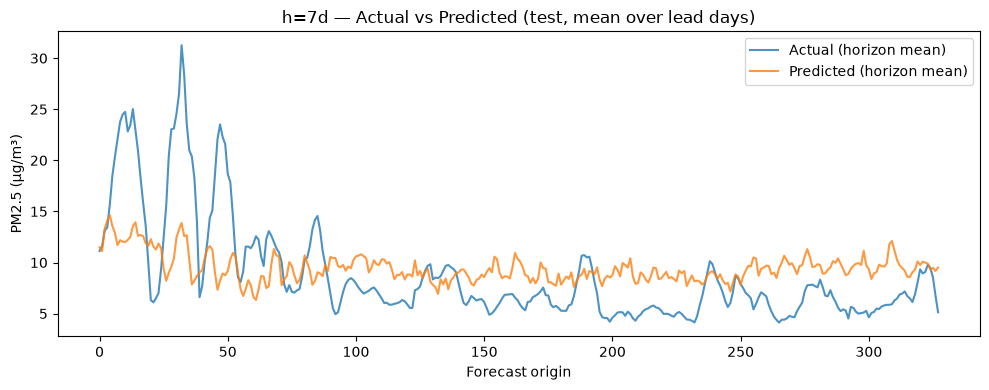

In [28]:
plot_actual_predicted_series(test_true_7, test_pred_7, horizon=7)


#### Predicted vs actual scatter (h=7)


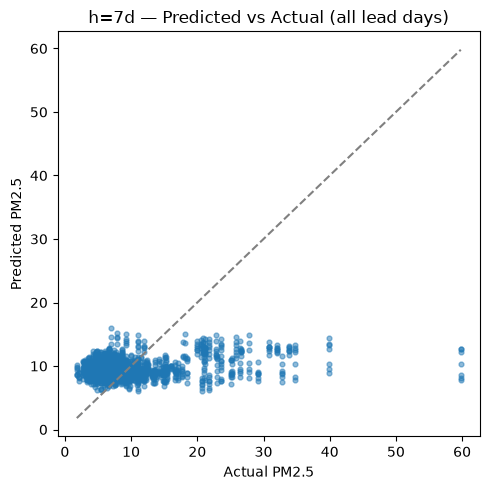

In [29]:
plot_predicted_vs_actual(test_true_7, test_pred_7, horizon=7)


### Evaluation — 14-day forecast horizon (test set)


In [33]:
model_14.eval()
with torch.no_grad():
    test_pred_14 = inverse_target(model_14(testX_14).detach().cpu().numpy())
test_true_14 = inverse_target(testY_14.cpu().numpy())

metrics_14 = compute_all_metrics(test_true_14.ravel(), test_pred_14.ravel())
print_all_metrics("Horizon 14d (test)", metrics_14)

ckpt = torch.load(save_path_14, map_location="cpu", weights_only=False)
ckpt["test_mae"] = metrics_14["MAE"]
ckpt["test_rmse"] = metrics_14["RMSE"]
torch.save(ckpt, save_path_14)


Horizon 14d (test)
  MAE:  4.231
  RMSE: 6.701
  R²:   0.012
  MAPE: 54.95%
  MSE:  44.903
  MBE:  -0.254


#### Actual vs predicted over time (h=14)


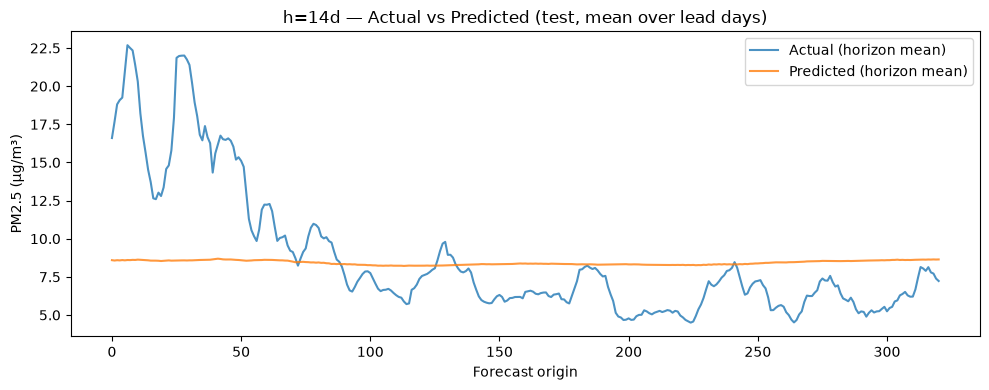

In [34]:
plot_actual_predicted_series(test_true_14, test_pred_14, horizon=14)


#### Predicted vs actual scatter (h=14)


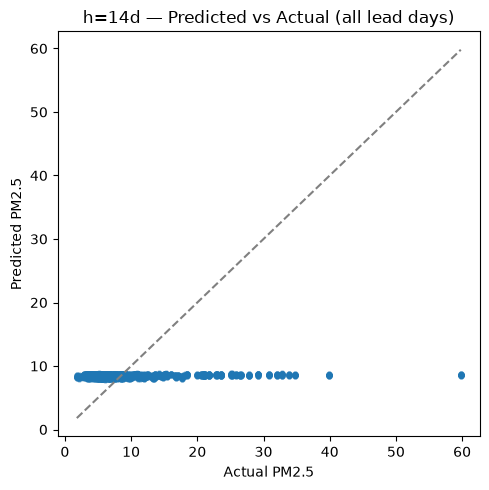

In [35]:
plot_predicted_vs_actual(test_true_14, test_pred_14, horizon=14)


### Evaluation — 30-day forecast horizon (test set)


In [36]:
model_30.eval()
with torch.no_grad():
    test_pred_30 = inverse_target(model_30(testX_30).detach().cpu().numpy())
test_true_30 = inverse_target(testY_30.cpu().numpy())

metrics_30 = compute_all_metrics(test_true_30.ravel(), test_pred_30.ravel())
print_all_metrics("Horizon 30d (test)", metrics_30)

ckpt = torch.load(save_path_30, map_location="cpu", weights_only=False)
ckpt["test_mae"] = metrics_30["MAE"]
ckpt["test_rmse"] = metrics_30["RMSE"]
torch.save(ckpt, save_path_30)


Horizon 30d (test)
  MAE:  4.436
  RMSE: 6.353
  R²:   0.056
  MAPE: 65.96%
  MSE:  40.358
  MBE:  0.989


#### Actual vs predicted over time (h=30)


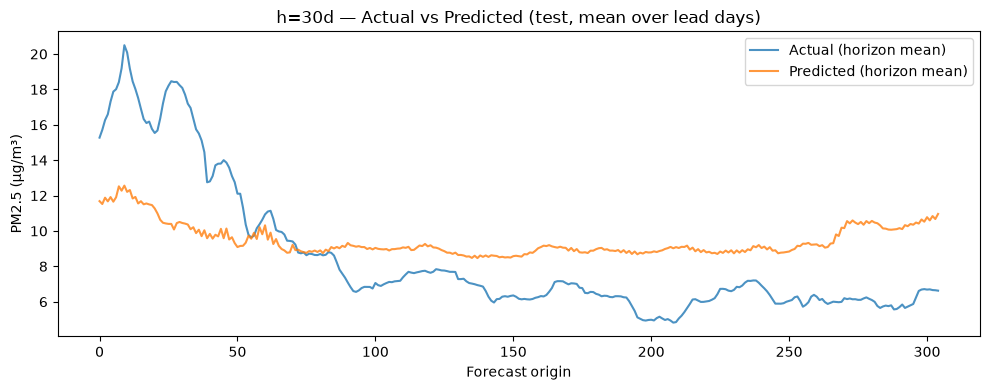

In [37]:
plot_actual_predicted_series(test_true_30, test_pred_30, horizon=30)


#### Predicted vs actual scatter (h=30)


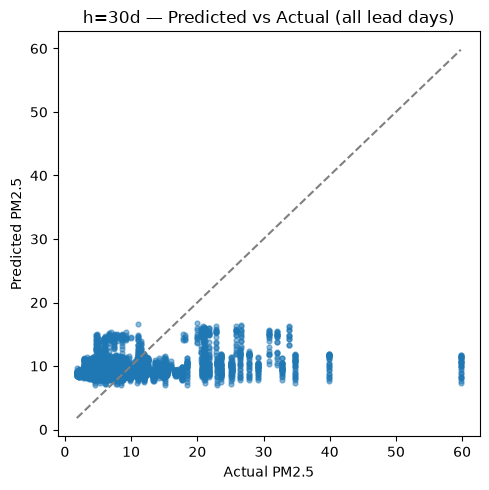

In [38]:
plot_predicted_vs_actual(test_true_30, test_pred_30, horizon=30)


### Mean-collapse check: predictions vs train/test means


Train mean PM2.5: 8.490 µg/m³
Test mean PM2.5:  9.196 µg/m³
h=7d: pred mean=9.426, actual mean=8.742
h=14d: pred mean=8.427, actual mean=8.681
h=30d: pred mean=9.443, actual mean=8.454


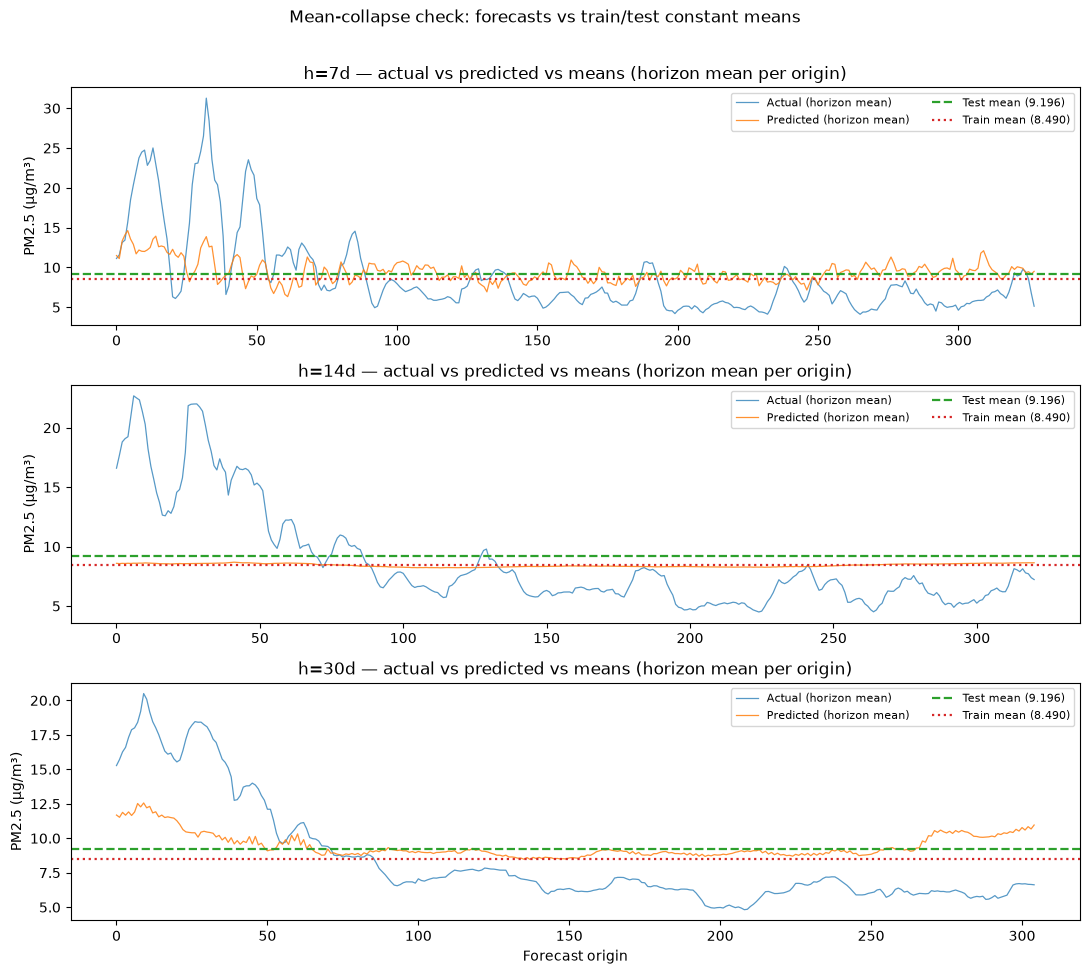

In [39]:
train_mean_pm25 = float(y_scaler.mean_[0])
test_mean_pm25 = float(y_test.mean())
print(f"Train mean PM2.5: {train_mean_pm25:.3f} µg/m³")
print(f"Test mean PM2.5:  {test_mean_pm25:.3f} µg/m³")

plot_mean_collapse_check(
    [
        (7, test_true_7, test_pred_7),
        (14, test_true_14, test_pred_14),
        (30, test_true_30, test_pred_30),
    ],
    train_mean=train_mean_pm25,
    test_mean=test_mean_pm25,
)


#### Mean-collapse check:

This check is whether the forecasts follow the test series or sit near a constant. The constants we care about are the training mean, 8.490 µg/m³, and the test mean, 9.196 µg/m³. A model that has given up on day-to-day variation will look like a flat line near one of those. A true mean collapse would be around the training mean, because the model has only seen that.


PatchTST does not track peaks and troughs at any of 7, 14, or 30 days. The predicted series is much flatter than the actuals. That part is the same failure. The level it flattens to is not.

The 7-day forecasts average 9.426 µg/m³ against an actual mean of 8.742, so they overpredict and sit near the test mean of 9.196 rather than the training mean of 8.490, possibly giving a false sense of reliability. The 14-day forecasts average 8.427 against 8.681, close to the training mean. This is a partial mean-collapse, but the model is still underpredicting on average. The 30-day forecasts average 9.443 against 8.454, high again, about 1 µg/m³ above the actuals. This makes it closer to the test mean than the training mean, this could give a false sense of reliability similar to the 7-day model. The 30-day model is not tracking the series, it is sitting near a level, and that level is above the actuals, similar to the 7-day model. 

### Metrics summary across horizons


In [40]:
metrics_summary = pd.DataFrame(
    [
        {"horizon": 7, **metrics_7},
        {"horizon": 14, **metrics_14},
        {"horizon": 30, **metrics_30},
    ]
).set_index("horizon")

display(metrics_summary.round(3))


,MAE,RMSE,R2,MAPE,MSE,MBE
horizon,,,,,,
7,4.563,6.485,0.080,64.775,42.057,0.684
14,4.231,6.701,0.012,54.947,44.903,-0.254
30,4.436,6.353,0.056,65.957,40.358,0.989


#### Per-lead-day test MSE


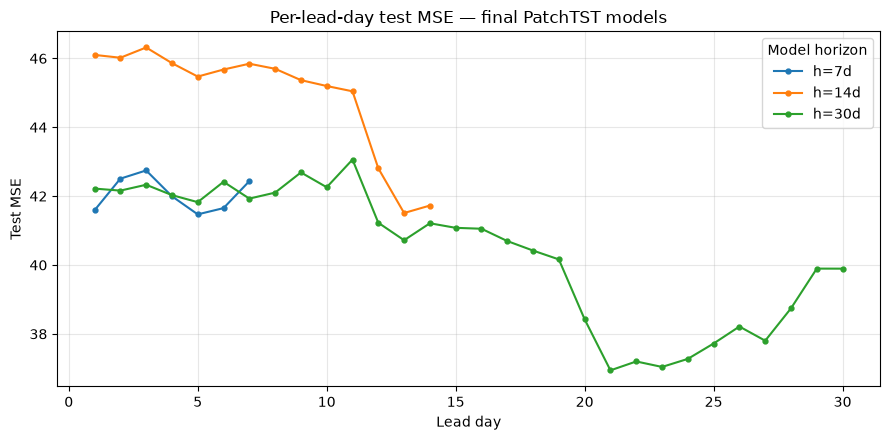

In [41]:
def per_lead_mse(y_true, y_pred):
    """Mean squared error for each lead day (axis 0 over samples)."""
    err = (np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)) ** 2
    return err.mean(axis=0)


mse_by_lead = {
    7: per_lead_mse(test_true_7, test_pred_7),
    14: per_lead_mse(test_true_14, test_pred_14),
    30: per_lead_mse(test_true_30, test_pred_30),
}

plt.figure(figsize=(9, 4.5))
for h, mse in mse_by_lead.items():
    days = np.arange(1, len(mse) + 1)
    plt.plot(days, mse, marker="o", markersize=3.5, linewidth=1.5, label=f"h={h}d")
plt.xlabel("Lead day")
plt.ylabel("Test MSE")
plt.title("Per-lead-day test MSE — final PatchTST models")
plt.legend(title="Model horizon")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Independent of the horizon, MSE is high, with all models hovering between ~46 and ~35 test MSE.

Interestingly, the 14 day model starts with the highest MSE on lead day 1, it does drop but still remains the highest across all lead days. The 7 day model starts with the lowest MSE on lead day 1, but by lead day 3 it is overtaken by the 30 day model, which then has the lowest MSE across all remaining lead days.

The 14-day model starts highest on lead day 1. It drops a little, but it stays the highest line on every remaining day. Tomorrow is already its worst comparison with the other two.

The 7-day model is lowest on lead day 1. By day 3 the 30-day model overtakes it and stays lowest for the rest of the chart. After about day 19 that 30-day line falls further, toward 35. Longer lead, lower error. That is backwards.

Shorter horizon should mean lower error. Here 14-day is worst the whole way, 7 day is only best at the start, and 30 day wins from day 3 because its line falls. The crossovers are MSE moving around across lead days, not error growing as the horizon lengthens. The 30 day model even drops further after about day 19. The 14 day model drops a little from its high start. The 7 day model does not.

### Metrics vs forecast horizon


In [42]:
horizons = metrics_summary.index.astype(str)


#### MAE by forecast horizon


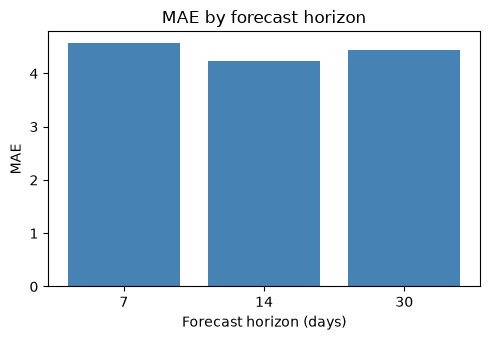

In [43]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MAE"], color="steelblue")
plt.title("MAE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


Overall MAE is 4.563 at 7 days, 4.231 at 14, and 4.436 at 30. Showing very little difference across horizons, and no clear trend.

This bar chart continues the story from the per-lead-day MSE chart. Shorter horizon should mean lower error. Here the 7-day bar is the highest and the 14-day bar is the lowest, with 30-day in between. Error does not grow as the horizon lengthens.

#### RMSE by forecast horizon


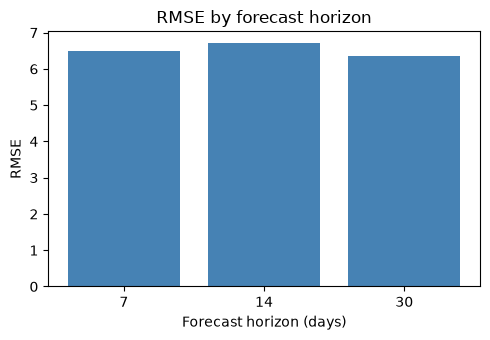

In [44]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["RMSE"], color="steelblue")
plt.title("RMSE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


RMSE is more sensitive to large misses than MAE. For PM2.5 a short spike can still trigger asthma or heart problems. If the model predicts 10 when the true value is 40, that is the miss RMSE is built to catch. It punishes it heavily. MAE treats it as one more 30 µg/m³ error.

Here RMSE is 6.485 at 7 days, 6.701 at 14, and 6.353 at 30. All three sit between about 6.4 and 6.7, well above the MAE of 4.2 to 4.6. The models are missing spikes. Ordinary days would not open a gap that size. The bars barely move.

#### R² by forecast horizon


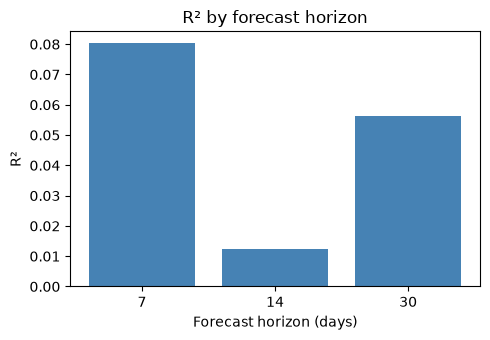

In [45]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["R2"], color="steelblue")
plt.title("R² by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("R²")
plt.tight_layout()
plt.show()


R² is the share of PM2.5 variation the model actually accounts for. Weather, traffic, industry, and pollution blowing in from elsewhere all move the series. If R² is high, those drivers are in the forecasts. If it is low, the model is missing them, including unusual episodes it has barely seen.

Here R² is 0.080 at 7 days, 0.012 at 14, and 0.056 at 30. The 7-day bar looks tall only because the axis stops at 0.08. Even the best of the three explains about 8% of the variation. The 14-day model explains about 1%. None of these has got hold of the series.

Shorter horizon should mean higher R². The 7-day bar is the highest, which fits, but then it collapses at 14 days and recovers at 30. Skill does not decay cleanly as the horizon lengthens.

#### MAPE by forecast horizon


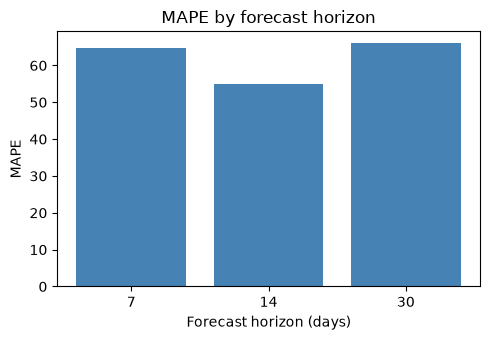

In [46]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MAPE"], color="steelblue")
plt.title("MAPE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MAPE")
plt.tight_layout()
plt.show()


Mean Absolute Percentage Error (MAPE) gives a sense of the relative error of the model's predictions compared to the actual values. So it compares each predictions to the corresponding actual value using its scale, then averages those relative errors across all predictions.

Here MAPE is 64.77% at 7 days, 54.95% at 14, and 65.96% at 30. A typical day is off by more than half the true concentration at every horizon. At 14 days that is about 55%. The 7-day and 30-day bars sit together near 65%. Relative error is high throughout.

#### MSE by forecast horizon


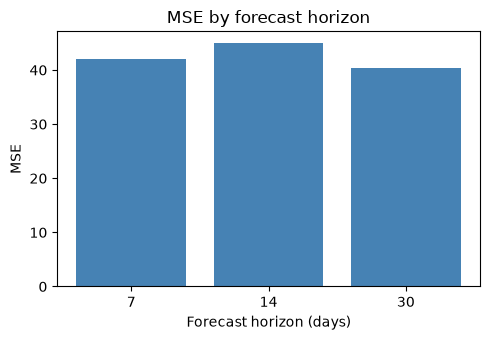

In [47]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MSE"], color="steelblue")
plt.title("MSE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()


MSE is what a lot of these models minimise in training, so the reported number is the same kind of error the optimiser saw. The units are (µg/m³)², which is why MAE and RMSE are easier to read. MSE still lines the evaluation up with the loss, and with papers that train on it. One thing to note is that we scale the target variable for training and validation, so the MSE reported here is on the inverse-transformed scale in µg/m³², so these values won't cleanly match the MSE reported during training, which is on the scaled target. The MSE reported here is on the original scale of the target variable.

Here MSE is 42.057 at 7 days, 44.903 at 14, and 40.358 at 30. The bars sit between about 40 and 45. This is high and flat across horizons, showing that when errors are squared (punishing large misses), the models are still missing spikes and not just being a bit off on ordinary days. Matching our RMSE thoughts.

#### MBE by forecast horizon


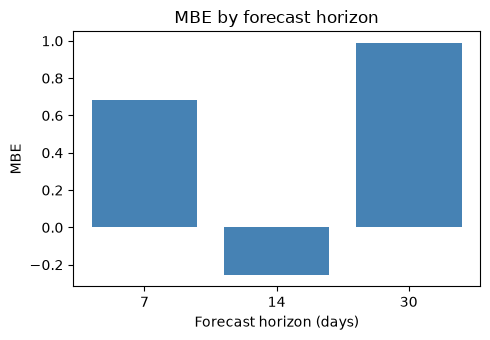

In [48]:
plt.figure(figsize=(5, 3.5))
plt.bar(horizons, metrics_summary["MBE"], color="steelblue")
plt.title("MBE by forecast horizon")
plt.xlabel("Forecast horizon (days)")
plt.ylabel("MBE")
plt.tight_layout()
plt.show()


MBE is the average signed miss, in µg/m³. Negative means the model is low. Positive means it is high. For PM2.5 the dangerous direction is low. If warnings follow the forecast, people can be in worse air than they were told. High bias wastes warnings and can wear down trust. Zero is the target.

Here MBE is 0.684 at 7 days, -0.254 at 14, and 0.989 at 30. The 7-day and 30-day models overpredict. The 14-day model underpredicts. That is the worse public-health error, even though it is closest to zero. Bias does not shrink as the horizon shortens. The 30-day bar is the largest overprediction, about 1 µg/m³ high on average.

### Feature importance (permutation)


In [49]:
def permutation_importance(model, X, y, feature_names, title, top_n=15):
    """Shuffle each feature; MAE increase (µg/m³) = importance."""
    model.eval()
    y_true = inverse_target(y.cpu().numpy()).ravel()

    with torch.no_grad():
        base_mae = mean_absolute_error(y_true, inverse_target(model(X).detach().cpu().numpy()).ravel())

    scores = {}
    for i, name in enumerate(feature_names):
        X_shuf = X.clone()
        # X is (batch, days, features)
        X_shuf[:, :, i] = X[torch.randperm(len(X), device=X.device), :, i]

        with torch.no_grad():
            shuf_mae = mean_absolute_error(
                y_true, inverse_target(model(X_shuf).detach().cpu().numpy()).ravel()
            )
        scores[name] = shuf_mae - base_mae

    ranked = sorted(scores.items(), key=lambda item: item[1])
    names, vals = zip(*ranked[-top_n:])

    plt.figure(figsize=(8, 5))
    plt.barh(names, vals, color="teal")
    plt.xlabel("MAE increase when shuffled (µg/m³)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return scores


#### Importance — 7-day model


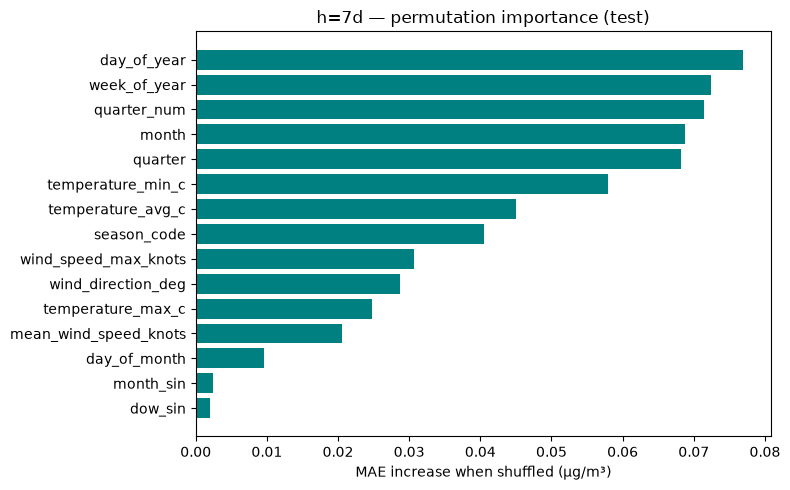

In [50]:
imp_7 = permutation_importance(
    model_7, testX_7, testY_7, feature_cols,
    title="h=7d — permutation importance (test)",
)


#### Importance — 14-day model


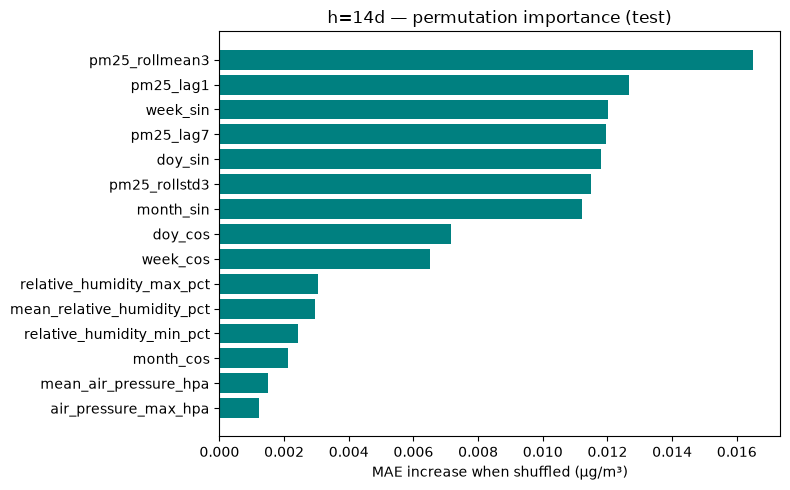

In [51]:
imp_14 = permutation_importance(
    model_14, testX_14, testY_14, feature_cols,
    title="h=14d — permutation importance (test)",
)


#### Importance — 30-day model


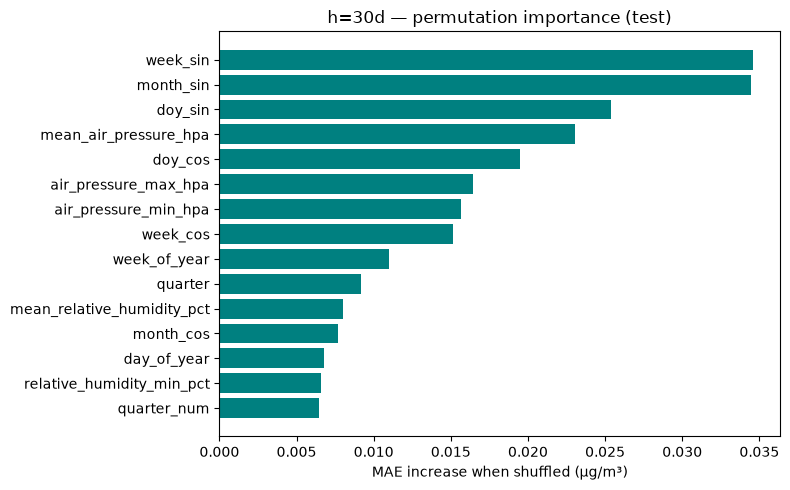

In [52]:
imp_30 = permutation_importance(
    model_30, testX_30, testY_30, feature_cols,
    title="h=30d — permutation importance (test)",
)


## Save permutation importance

All features, not only the plotted top 15. One file per horizon for the ranking table.


In [53]:
def permutation_table(scores):
    return (
        pd.DataFrame(
            {"Feature": list(scores.keys()), "Importance_Mean": list(scores.values())}
        )
        .sort_values("Importance_Mean", ascending=False)
        .reset_index(drop=True)
    )


for h, scores in [(7, imp_7), (14, imp_14), (30, imp_30)]:
    path = RESULTS_DIR / f"transformer_permutation_importance_{h}d.csv"
    permutation_table(scores).to_csv(path, index=False)
    print("Saved", path.resolve())


Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/transformer_results/transformer_permutation_importance_7d.csv
Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/transformer_results/transformer_permutation_importance_14d.csv
Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/transformer_results/transformer_permutation_importance_30d.csv


### Feature importance across horizons


Each bar is the test MAE rise after shuffling that feature across windows. Test MAE is already 4.563, 4.231, and 4.436 µg/m³. No feature dominates our predictions.

The 7-day chart is almost all calendar. quarter is about 0.081 µg/m³, then month, quarter_num, day_of_year, and week_of_year. Min and mean temperature sit under those. Wind is weak. Humidity, day_of_month, and is_weekend barely move. Recent PM2.5 is not in the top 15. The model is using temperature and time of year to make its predictions.

Fourteen days is the odd one. Recent PM2.5 ranks first, pm25_rollmean3, pm25_lag1, pm25_lag7, pm25_rollstd3, then month_sin, week_sin, and doy_sin. The largest bar for that model is about 0.0175 µg/m³, very little next to our overall MAE. Compared with the others, this model is relying on historical PM2.5 patterns rather than calendar features directly.

At 30 days the sine and cosine season terms are back on top. month_sin is about 0.037, then week_sin, doy_sin, week_cos, and doy_cos, Air pressure follows then raw month and week_of_year sit below those.

7 and 30 days are seasonal and the 14 days model relies on recent PM2.5, but 0.0175 µg/m³ is not a strong two week pollution signal. month, quarter, and day_of_year are the same seasonal information split across correlated columns, so none of those bars is a unique driver and even then, the feature importance is very low. The model is not using any feature strongly, and the 14-day model is relying on a weak signal from recent PM2.5, the others are relying on seasonal information, but the model is not using any feature strongly over another.

#### Analysis Summary:
Grid search with time series cross validation picked a learning rate of 0.001 and two transformer layers for all three horizons, and agreed on nothing else. The 7-day model used the largest embedding, d_model=64, stronger L2 at weight_decay=0.001, and the  more summarized patch length of 10. The 14-day model used d_model=32, the same weight decay, and patch_length=2. The 30-day model used d_model=64, weaker L2 at 0.0001, and patch_length=2. These are best read as whatever happened to win on mean CV MAE with the data we have, not as evidence that longer horizons genuinely need different capacity. Each final model was then fitted on a time ordered train/validation split with early stopping on validation MSE. The patch lengths didn't seem to matter much, and the winners were not clearly better than the other configurations. The fold spread was large enough that the ranking is not reliable.


On the test set PatchTST shows weak skill at 7 days, an R² of 0.080 and MAE of 4.563 µg/m³. R² falls to 0.012 at 14 days and is 0.056 at 30. All three are close to a constant forecast at the test set mean of 9.196 µg/m³. MAE does not rise with horizon, 4.563, 4.231, and 4.436. RMSE stays high throughout, 6.485, 6.701, and 6.353. MAPE is high at every horizon. MBE is mixed, 0.684, −0.254, and 0.989. Predicted means are 9.426, 8.427, and 9.443 against actuals of 8.742, 8.681, and 8.454, so the 7 and 30-day models overpredict and the 14-day model underpredicts. The prediction plots and permutation importance match that picture. At 7 and 30 days the network relies on seasonality rather than recent PM2.5, with 14 days recent PM2.5 ranking first, but the largest feature permutation score is only about 0.0175 µg/m³. It has attempted to learn historical PM2.5 patterns, not day to day variation factors of PM2.5. 30 and 7 days did have marginally larger feature importance bars, but still very small compared to the overall MAE. The model is not capturing the available signal reliably at these horizons.

With 1,000 training days, a 30 day input window, and multistep targets, the usable sample size is small. Mean CV MAE only moved about 0.10 µg/m³ from the first grid point to the winner, inside a fold spread of about ±0.8. That contrast is hard to trust. The model never captured the signal confidently, and the gap between hyperparameter configurations on CV was tiny.

PM2.5 values in this dataset only have modest short term predictability, and PatchTST is a heavy model for a dataset this size. It does not capture the available signal reliably at these horizons. The forecasts stay too flat, and at two weeks they are no better than a near mean guess.

## Next-day horizon sanity check (h=1)

I wanted to validate the model's performance on a next-day forecast horizon (h=1) to ensure that it can accurately predict the target variable for the immediate next day. This serves as a sanity check to confirm that the model is capable of capturing short-term dependencies in the data.

This run uses the same grid search and time-series CV as the 7, 14, and 30-day models, so h=1 gets its own hyperparameters.

In [54]:
# Sequences for horizon = 1 (scaled targets)
trainX_1, trainY_1 = make_tensors(X_train_scaled, y_train_scaled, 1)  # 1 day horizon
testX_1, testY_1 = make_tensors(X_test_scaled, y_test_scaled, 1)  # 1 day horizon
print("train:", tuple(trainX_1.shape), "test:", tuple(testX_1.shape))



train: (970, 30, 40) test: (334, 30, 40)


#### Grid search (h=1)


Grid search for horizon=1d
  new best [1/144] CV MAE=3.569 ± 0.866  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 2}
  new best [3/144] CV MAE=3.555 ± 0.791  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0, 'patch_length': 10}
  new best [6/144] CV MAE=3.543 ± 0.793  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.0001, 'patch_length': 10}
  new best [9/144] CV MAE=3.536 ± 0.794  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 1, 'weight_decay': 0.001, 'patch_length': 10}
  new best [13/144] CV MAE=3.500 ± 0.857  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 2}
  new best [15/144] CV MAE=3.449 ± 0.831  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0, 'patch_length': 10}
  new best [18/144] CV MAE=3.448 ± 0.833  {'learning_rate': 0.001, 'd_model': 16, 'num_layers': 2, 'weight_decay': 0.0001, 'patch_leng

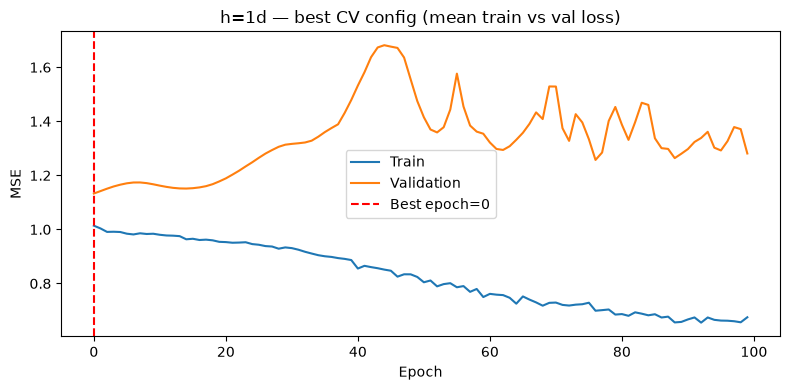

In [55]:
print("Grid search for horizon=1d")
results_df_1, best_1 = cv_grid_search(trainX_1, trainY_1)
best_params_1 = best_1["params"]
best_epoch_1 = best_1["best_epoch"]
print("\nBest params (by mean CV MAE):", best_params_1)
print(f"CV MAE = {best_1['val_mae']:.3f}")
print(f"CV best epoch = {best_epoch_1}")
plot_train_val_loss(
    best_1["train_losses"],
    best_1["val_losses"],
    best_epoch=best_epoch_1,
    title="h=1d — best CV config (mean train vs val loss)",
    val_label="Validation",
)


#### Hyperparameter tuning plots (h=1)


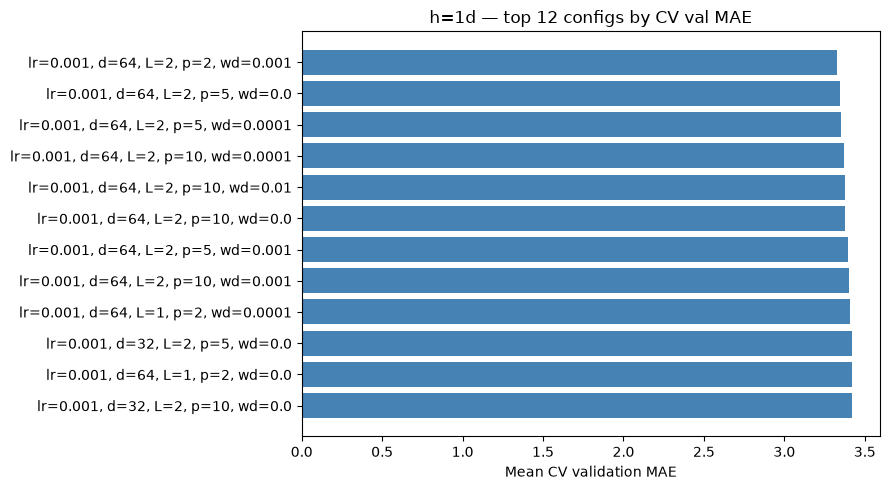

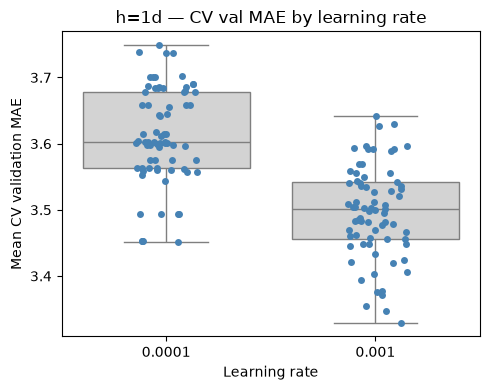

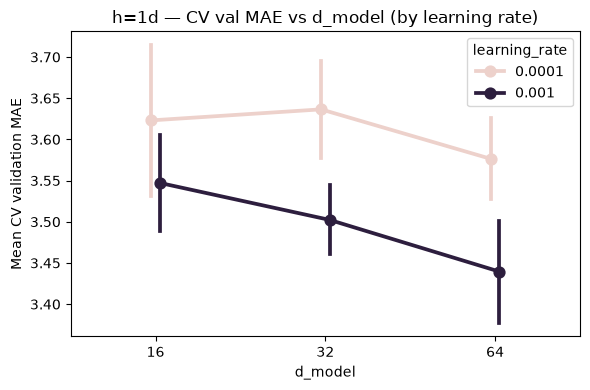

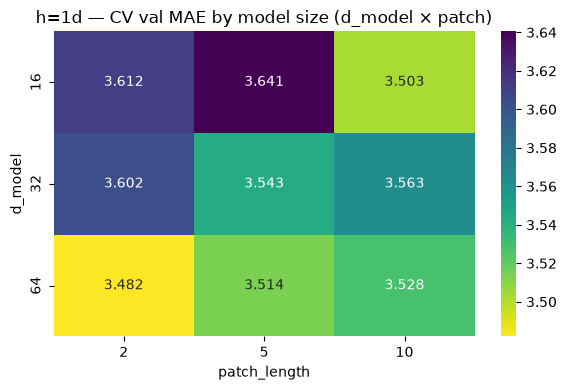

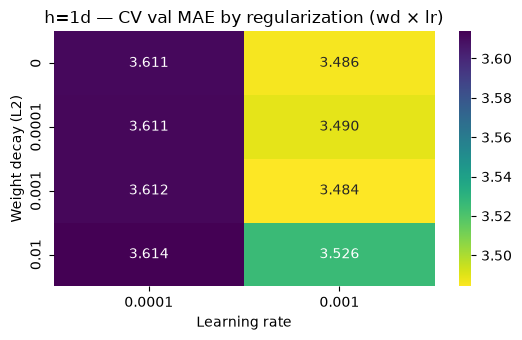

In [58]:
plot_tuning_results(results_df_1, horizon=1)


#### Final fit (h=1)


In [59]:
torch.manual_seed(42)
model_1 = build_model(
    best_params_1["d_model"],
    best_params_1["num_layers"],
    best_params_1["patch_length"],
    horizon=1,
)

fitX_1, fitY_1, valX_1, valY_1 = time_ordered_train_val_split(
    trainX_1, trainY_1, FINAL_VAL_FRACTION
)
train_losses_1, val_losses_1, best_epoch_1_final = train_model(
    model_1,
    fitX_1,
    fitY_1,
    valX_1,
    valY_1,
    lr=best_params_1["learning_rate"],
    weight_decay=best_params_1["weight_decay"],
    epochs=NUM_EPOCHS,
    log_every=None,
    restore_best=True,
    patience=EARLY_STOP_PATIENCE,
)
print(
    f"Final fit h=1d: ran {len(train_losses_1)} epochs; "
    f"restored best validation epoch={best_epoch_1_final}"
)



Early stopping at epoch 466 (no validation improvement for 200 epochs; best=266)
Final fit h=1d: ran 467 epochs; restored best validation epoch=266


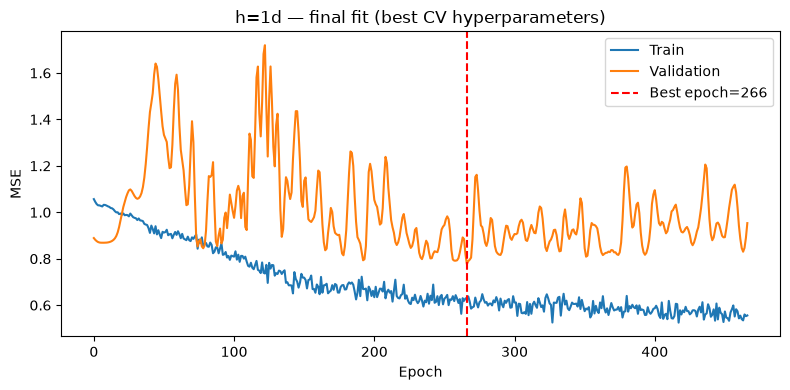

In [60]:
plot_train_val_loss(
    train_losses_1,
    val_losses_1,
    best_epoch=best_epoch_1_final,
    title="h=1d — final fit (best CV hyperparameters)",
    val_label="Validation",
)



### Evaluation on 1-day forecast horizon (test set)


In [61]:
model_1.eval()
with torch.no_grad():
    test_pred_1 = inverse_target(model_1(testX_1).detach().cpu().numpy())
test_true_1 = inverse_target(testY_1.cpu().numpy())

metrics_1 = compute_all_metrics(test_true_1.ravel(), test_pred_1.ravel())
print_all_metrics("Horizon 1d (test)", metrics_1)


Horizon 1d (test)
  MAE:  4.364
  RMSE: 6.773
  R²:   -0.011
  MAPE: 56.94%
  MSE:  45.875
  MBE:  -0.178


## Save test metrics CSV

Lead 1 plus pooled-path 7 / 14 / 30. Same columns as `pooled_path_comparison.ipynb`.


In [62]:
row_1 = {"Horizon_Days": 1, **metrics_1}
pooled = (
    metrics_summary.reset_index()
    .rename(columns={"horizon": "Horizon_Days"})
)
test_metrics = pd.concat([pd.DataFrame([row_1]), pooled], ignore_index=True)
test_metrics = test_metrics[
    ["Horizon_Days", "MAE", "RMSE", "R2", "MAPE", "MSE", "MBE"]
]
path = RESULTS_DIR / "transformer_test_metrics.csv"
test_metrics.to_csv(path, index=False)
print("Saved", path.resolve())
display(test_metrics.round(4))


Saved /Users/matthewbutler/Documents/MastersPaper/code/model_training/transformer_results/transformer_test_metrics.csv


,Horizon_Days,MAE,RMSE,R2,MAPE,MSE,MBE
0,1,4.3642,6.7731,-0.0113,56.9371,45.8750,-0.1775
1,7,4.5625,6.4851,0.0802,64.7748,42.0568,0.6840
2,14,4.2310,6.7010,0.0124,54.9474,44.9033,-0.2545
3,30,4.4358,6.3528,0.0565,65.9574,40.3577,0.9889


#### Actual vs predicted over time (h=1)


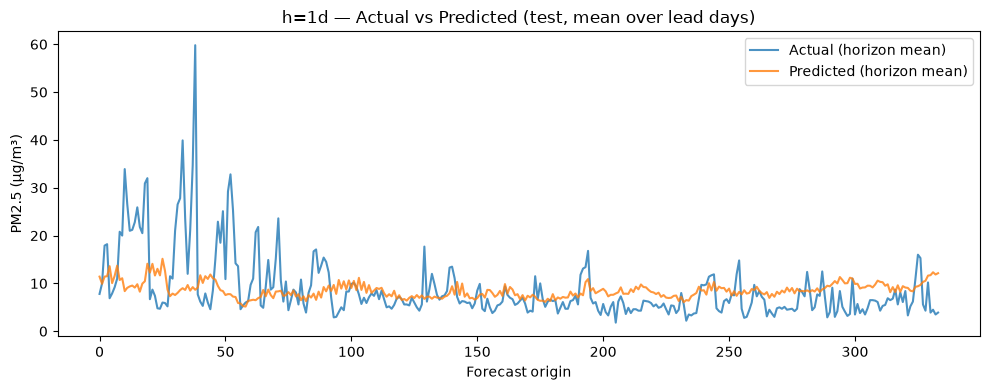

In [63]:
plot_actual_predicted_series(test_true_1, test_pred_1, horizon=1)


#### Predicted vs actual scatter (h=1)


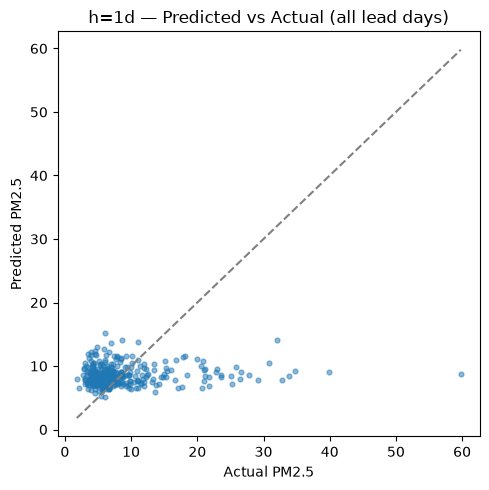

In [64]:
plot_predicted_vs_actual(test_true_1, test_pred_1, horizon=1)


#### Metrics summary across horizons (h=1):

This model even failed on the next-day horizon. With an R² of -0.011 and an MAE of 4.364, showing that the model is not capturing the signal even for the immediate next day.